## Set up data and model objects

In [1]:
import pandas as pd
import numpy as np

from torch.distributions import NegativeBinomial
from pyro.distributions import LogNormalNegativeBinomial

from lightning.pytorch.callbacks import ModelCheckpoint

import mudata as md
import perturbo
import seaborn as sns
import pyro
import matplotlib.pyplot as plt
import torch

smoke_test=True # only use selected genes
# smoke_test=False # run full analysis


torch.cuda.device_count()

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0

In [2]:
import scvi
scvi.settings.seed = 0

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (
Global seed set to 0


Set training configuration and access to data

### Load the data
(50k cells, takes ~30 seconds)

In [3]:
data_dir = "../../../../Data/gasperini_pilot"
batch_size=4096 # multiple of 64

mdata = md.read_h5mu(f'{data_dir}/gasperini_pilot_highMOI.h5mu')
# batch_size=None
mdata

KeyboardInterrupt: 

In [ ]:
np.median(mdata["rna"].X.sum(axis=1).A1)

14917.0

In [ ]:
# data_dir = "/data/pinello/SHARED_DATA/gasperini_2019"
# data_dir = "/work/data/SHARED_DATA/gasperini_2019"

selected_guides = mdata["grna"].var_names[:110]
# selected_guides = ["ACTB_TSS|1", "ACTB_TSS|2", "ACTG1_TSS|1", "ACTG1_TSS|2"]
selected_genes = sorted({sg.split("_")[0] for sg in selected_guides})
selected_genes = [g for g in selected_genes if g in mdata["rna"].var_names]
if torch.cuda.is_available():
    accelerator = "gpu"
    print("training using GPU")
else:
    accelerator = "cpu"
    print("training using CPU")
print(len(selected_genes))

training using CPU
50


In [ ]:
if smoke_test:
    n_steps = 1
else:
    n_steps = scvi.model._utils.get_max_epochs_heuristic(len(mdata), epochs_cap=1000, decay_at_n_obs=5000)
n_steps

1

In [ ]:
sceptre_df = pd.read_csv(f"{data_dir}/sceptre_results-2023_01_13.csv")
sceptre_df = sceptre_df.rename(columns={"gRNA_id": "guide", "gene_id": "gene", "z_value":"SCEPTRE_z_value","p_value":"SCEPTRE_p_value"})
sceptre_df


,gene,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change
0,Y_RNA,ACTB_TSS|1,positive_control,0.940707,1.632176,0.469126
1,FOXK1,ACTB_TSS|1,positive_control,0.153629,-0.992648,-0.088097
2,AP5Z1,ACTB_TSS|1,positive_control,0.123562,-1.010549,-0.119240
3,RADIL,ACTB_TSS|1,positive_control,0.057483,-1.501497,-0.386814
4,RNF216P1,ACTB_TSS|1,positive_control,0.341734,-0.635756,-0.034944
...,...,...,...,...,...,...
22261,SNORD60,scrambled_9|2,negative_control,0.950426,1.765242,0.708387
22262,DCAKD,scrambled_9|2,negative_control,0.488787,-0.149950,-0.027133
22263,RNF213-AS1,scrambled_9|2,negative_control,0.847978,1.018406,0.507472
22264,NAPB,scrambled_9|2,negative_control,0.696904,0.508168,0.149431


In [ ]:
if not smoke_test or selected_genes is None:
    selected_genes = sceptre_df["gene"].unique()
if not smoke_test or selected_guides is None:
    selected_guides = sceptre_df["guide"].unique()

print(len(selected_genes), len(selected_guides))
# sceptre_df.query("guide=='GATA2_TSS|1'")


50 110


In [ ]:
sceptre_df.query("pair_type=='negative_control'")

,gene,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change
21272,Metazoa_SRP,random_1|1,negative_control,0.225595,-0.745345,-0.331922
21273,OR2G6,random_1|1,negative_control,0.985559,2.585539,0.942606
21274,SLC3A2,random_1|1,negative_control,0.874096,1.930871,0.153495
21275,PTPN11,random_1|1,negative_control,0.685826,0.454581,0.040252
21276,CORO7,random_1|1,negative_control,0.847094,1.114626,0.175454
...,...,...,...,...,...,...
22261,SNORD60,scrambled_9|2,negative_control,0.950426,1.765242,0.708387
22262,DCAKD,scrambled_9|2,negative_control,0.488787,-0.149950,-0.027133
22263,RNF213-AS1,scrambled_9|2,negative_control,0.847978,1.018406,0.507472
22264,NAPB,scrambled_9|2,negative_control,0.696904,0.508168,0.149431


In [ ]:
grna_subset = mdata.mod['grna'][:,selected_guides]
# grna_subset.X *= 0 # NO GUIDE INFLUENCE
rna_subset = mdata.mod['rna'][:,selected_genes]
mdata = md.MuData({'rna':rna_subset, 'grna':grna_subset}).copy()
mdata

MuData object with n_obs × n_vars = 47964 × 160
  2 modalities
    rna:	47964 x 50
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 110
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [ ]:
mdata['grna'].varm['element_targeted']


,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,scrambled_24,scrambled_25,scrambled_2,scrambled_3,scrambled_4,scrambled_5,scrambled_6,scrambled_7,scrambled_8,scrambled_9
ACTB_TSS|1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHRAC1_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CITED2_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CITED2_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CKB_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Register data with perturbo

In [ ]:
# element_names1 = model.adata_manager.get_state_registry("tested_elements")['column_names']
# element_names2 = model.adata_manager.get_state_registry("targeted_elements")['column_names']
# assert element_names1 == element_names2

In [ ]:
# %pip install scikit-misc

In [ ]:
# sc.pp.highly_variable_genes(mdata['rna'], flavor='seurat_v3', batch_key="bath_number", n_top_genes=1000)
# # sc.pp.neighbors(mdata['rna'])
# sc.tl.pca(mdata['rna'])


In [ ]:
mdata['rna'].obs

,bath_number,percent_mito,log_number_of_detected_genes,log_total_gene_count,log_total_guide_count,library_size
TTGAACGCAAGCGAGT,6,0.029057,8.385489,8.385717,7.330405,20602.0
ATTACTCGTGGTAACG,1,0.025976,8.254529,8.254789,5.986452,14048.0
GTAGTCATCGTTGACA,5,0.042747,8.206584,8.206856,5.225747,13701.0
GTGTGCGTCCCGACTT,4,0.042587,8.327726,8.327968,5.700444,17474.0
GCATGCGAGAAACGAG,3,0.021318,7.806289,7.806696,7.071573,8807.0
...,...,...,...,...,...,...
GGAATAATCTGGGCCA,3,0.091893,8.316056,8.316300,5.793014,15244.0
GTCCTCATCTTGTATC,6,0.043563,7.293698,7.294377,6.093570,3588.0
CCACTACGTAGAGCTG,6,0.021208,8.134761,8.135054,6.400258,12897.0
CGTTCTGAGGATGGTC,6,0.025178,8.203851,8.204125,5.730100,13752.0


In [ ]:
mdata[mdata['rna'].obs['percent_mito']<0.1,:]

View of MuData object with n_obs × n_vars = 47679 × 160
  2 modalities
    rna:	47679 x 50
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47679 x 110
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scanpy/plotting/_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


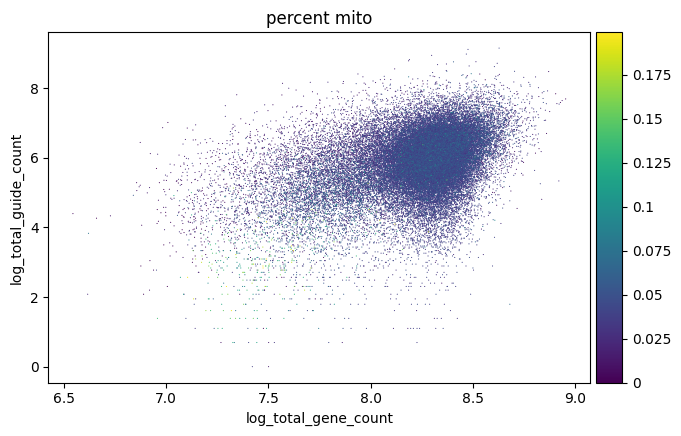

In [ ]:
# mdata.update()
import scanpy as sc

# mdata = mdata[mdata['rna'].obs['percent_mito']<0.1,:].copy()
# mdata = mdata[mdata['rna'].obs['log_total_gene_count'].between(8.1,8.5),:].copy()
sc.pl.scatter(mdata['rna'],"log_total_gene_count", "log_total_guide_count", "percent_mito")
# mdata

In [ ]:
# sc.pl.pca(mdata['rna'], color="bath_number")
# sc.pl.pca(mdata['rna'], color="percent_mito")
mdata['rna'].X.mean(axis=0).shape

(1, 50)

In [ ]:
perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="bath_number",
    library_size_key="library_size",
    continuous_covariates_keys=["log_total_guide_count", "percent_mito"],
    guide_by_element_key="element_targeted",
    gene_by_element_key="element_tested",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbo.PERTURBO(mdata, likelihood="nb", n_factors=None)
model.view_anndata_setup()


INFO     Using column names from columns of adata.varm['element_tested']                                           
INFO     Using column names from columns of adata.varm['element_targeted']                                         


<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For cre

Anndata setup with scvi-tools version 1.0.4.

Setup via `PERTURBO.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'perturbation_layer': None,
│   'batch_key': 'bath_number',
│   'gene_by_element_key': 'element_tested',
│   'rna_element_uns_key': None,
│   'guide_element_uns_key': None,
│   'guide_by_element_key': 'element_targeted',
│   'library_size_key': 'library_size',
│   'size_factor_key': None,
│   'continuous_covariates_keys': ['log_total_guide_count', 'percent_mito'],
│   'categorical_covariates_keys': None,
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'}
}

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   6   │
│         n_cells         │ 47964 │
│ n_extra_continuous_covs │   2   │
│  n_gene_summary_stats   │   1   │
│     n_perturbations     │  110  │
│   n_targeted_elements   │ 1561  │
│    n_tested_elements    │ 1561  │
│         n_vars          │  50   │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│  gene_summary_stats   │  adata.mod['rna'].varm['_scvi_gene_summary_stats']   │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │      adata.mod['grna'].varm['element_targeted']      │
│    tested_elements    │       adata.mod['rna'].varm['element_tested']        │
└───────────────────────┴──────────────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['bath_number'] │     1      │          0          │
│                          │     2      │          1          │
│                          │     3      │          2          │
│                          │     4      │          3          │
│                          │     5      │          4          │
│                          │     6      │          5          │
└──────────────────────────┴────────────┴─────────────────────┘

 gene_summary_stats State  
         Registry          
┏━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.var['_gene_mean'] │
└─────────────────────────┘

 extra_continuous_covs State Registry 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃          Source Location           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['log_total_guide_count'] │
│     adata.obs['percent_mito']      │
└────────────────────────────────────┘

### Train the model

In [ ]:
list(pyro.get_param_store().keys())


[]

In [ ]:
# burn-in
pyro.clear_param_store()

# len(mdata['rna'])/batch_size
# # 0.9**(1/11)# from pyro.optim import ClippedAdam
from torch.optim import Adam
from pyro.infer import TraceMeanField_ELBO
from math import ceil
from torch.optim.lr_scheduler import ReduceLROnPlateau
optimizer = Adam

# scheduler = ReduceLROnPlateau(optimizer, patience=2, verbose=True)
steps_per_epoch = ceil(model.module.n_cells / batch_size)
# scheduler = pyro.optim.MultiStepLR(
#     {
#         "optimizer": optimizer,
#         "optim_args": {"lr": 0.1},
#         "gamma": 0.3,
#         # "milestones": [steps_per_epoch * 10, steps_per_epoch*20],
#         "milestones": [10, 20],
#     }
# )

# scheduler = pyro.optim.ReduceLROnPlateau(
#     {
#         "optimizer": optimizer,
#         "optim_args": {"lr": 0.1},
#         "threshold": 1e-2,
#         "patience": 5,
#         "factor": 0.3,
#     }
# )


def plot_gene_distribution(medians, gene_name="ACTB", x_max=100, log_y_scale=False):
    gene_idx = np.where(mdata["rna"].var_names == gene_name)[0][0]
    tss_guides = mdata["grna"].var_names[mdata["grna"].var_names.str.startswith(gene_name + "_TSS")]
    has_tss_guide = mdata["grna"][:, tss_guides].X.sum(axis=1) > 0
    data_df = mdata["rna"][:, gene_idx].to_df()
    data_df["has_TSS_guide"] = has_tss_guide
    print(has_tss_guide.shape)
    print(tss_guides)
    log_gene_means = medians["log_gene_mean"]
    log_gene_dispersions = medians["log_gene_dispersion"]
    x = torch.tensor(np.arange(x_max))
    logit = log_gene_means[gene_idx]
    total_count = log_gene_dispersions[gene_idx].exp()
    if model.module.likelihood == "nb":
        ndist = NegativeBinomial(logits=logit - total_count.log(), total_count=total_count)
    elif model.module.likelihood == "lnnb":
        multiplicative_noise = medians["multiplicative_noise"][gene_idx]
        ndist = LogNormalNegativeBinomial(
            logits=logit - total_count.log() - multiplicative_noise**2 / 2,
            total_count=total_count,
            multiplicative_noise_scale=multiplicative_noise,
            num_quad_points=32,
        )
    probs = ndist.log_prob(x).exp()
    plt.plot(x, probs)
    sns.histplot(data_df, x=gene_name, bins=x, stat="density", hue="has_TSS_guide")
    plt.title(f'gene: {mdata["rna"].var_names[gene_idx]}')
    print(f'logit={logit:.2f}, total_count={total_count:.2f}')
    if model.module.likelihood == "lnnb":
        print(f'multiplicative_noise={multiplicative_noise:.2f}')
    if log_y_scale:
        plt.semilogy()
    plt.show()
    return data_df

In [ ]:
# model.train(
#     1,
#     lr=0.000001,
#     batch_size=128,
#     accelerator=accelerator,
# )
# plot_gene_distribution(model.module.guide.median())

In [ ]:
model

MyPyroModel Model with params:
n_batch: 6
n_cells: 47964
n_extra_continuous_covs: 2
n_gene_summary_stats: 1
n_perturbations: 110
n_targeted_elements: 1561
n_tested_elements: 1561
n_vars: 50

Training status: Not Trained
Model's adata is minified?: False

In [ ]:
from lightning.pytorch.callbacks import Callback

medians = []
# n_epochs=100
# for _ in range(n_epochs):

checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints/", every_n_epochs=10, save_top_k=-1, save_on_train_epoch_end=True
)



# model.train(
#     100,
#     lr=0.003,
#     batch_size=512,
#     callbacks=[checkpoint_callback],
#     enable_checkpointing=True,
#     early_stopping=True,
#     early_stopping_patience=2,
#     early_stopping_min_delta=1e-2,
#     early_stopping_monitor="elbo_train",
# )

model.train(
    100,
    lr=0.01,
    batch_size=512,
    callbacks=[checkpoint_callback],
    enable_checkpointing=True,
    early_stopping=True,
    early_stopping_patience=2,
    early_stopping_min_delta=1e-2,
    early_stopping_monitor="elbo_train",
)


# medians.append(model.module.guide.median())

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:617: UserWarning: Checkpoint directory checkpoints/ exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
/Users/l

Epoch 1/100:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 9/100:   8%|▊         | 8/100 [00:06<01:17,  1.19it/s, v_num=1, elbo_train=4.36e+6]

In [ ]:
# checkpoint = torch.load("checkpoints/epoch=9-step=660.ckpt")
# checkpoint = torch.load("checkpoints/epoch=89-step=5940.ckpt")

# state_model.module.load_state_dict(checkpoint["state_dict"])
# offset = len("module.")
# new_dict = {k[len("module."):]: v for k, v in checkpoint["state_dict"].items() if k != "_dummy_param"}

# model.module.load_state_dict(new_dict)
# model.module.guide.median()åååå
# for k, v in checkpoint["state_dict"].items():
    # print(k)

In [ ]:
mdata

MuData object with n_obs × n_vars = 47964 × 160
  uns:	'_scvi_uuid', '_scvi_manager_uuid'
  2 modalities
    rna:	47964 x 50
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size', '_size_factor', '_ind_x', '_scvi_batch'
      var:	'_gene_mean'
      obsm:	'_scvi_extra_continuous_covs'
      varm:	'element_tested', '_scvi_gene_summary_stats'
    grna:	47964 x 110
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [ ]:
posterior_means = model.module.guide.median()
posterior_means.keys()

dict_keys(['guide_efficacy', 'log_gene_mean', 'log_gene_dispersion', 'batch_effect', 'cont_covariate_effect', 'element_effects'])

(array([  3.,   2.,   2.,  10.,  10.,   6.,   3.,   7.,   4., 189.]),
 array([-1.81280875, -1.6271652 , -1.44152164, -1.25587809, -1.07023466,
        -0.8845911 , -0.69894755, -0.513304  , -0.32766047, -0.14201693,
         0.04362661]),
 <BarContainer object of 10 artists>)

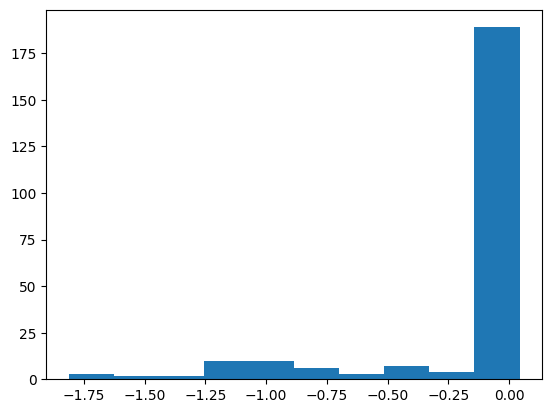

In [ ]:
plt.hist(posterior_means["element_effects"])

In [ ]:
gene_means = mdata["rna"].X.mean(axis=0).A1
gene_params = pd.DataFrame(
    {"gene": mdata["rna"].var_names, "mean": gene_means, "dispersion": posterior_means["log_gene_dispersion"].exp()}
)
gene_params.to_csv("gasperini_pilot_50_gene_params.csv")
# sorted(posterior_means["log_gene_mean"].numpy())
# plt.hist(posterior_means["log_gene_dispersion"])

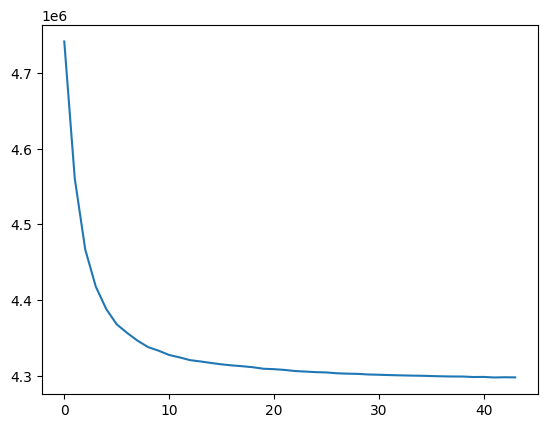

In [ ]:
plt.plot(model.history["elbo_train"])

In [ ]:
# efficacy = torch.stack([m["guide_efficacy"].squeeze() for m in medians])
# for i, guide in enumerate(mdata["grna"].var_names):
#     plt.plot(range(n_epochs), efficacy[:,i], label=guide)
# plt.legend()

In [ ]:
# mean = torch.stack([m["log_gene_mean"].squeeze() for m in medians])
# for i, guide in enumerate(mdata["rna"].var_names):
#     plt.plot(range(n_epochs), mean[:,i], label=guide)
# plt.legend()

In [ ]:
# disp = torch.stack([m["log_gene_dispersion"].squeeze() for m in medians])
# for i, guide in enumerate(mdata["rna"].var_names):
#     plt.plot(range(n_epochs), disp[:,i], label=guide)
# plt.legend()
# plt.title("log gene dispersion")

In [ ]:
# extra_noise = torch.stack([m["multiplicative_noise"].squeeze() for m in medians])
# for i, guide in enumerate(mdata["rna"].var_names):
#     plt.plot(range(n_epochs), extra_noise[:,i], label=guide)
# plt.legend()
# plt.title("extra multiplicative noise")

(47964,)
Index(['ACTB_TSS|1', 'ACTB_TSS|2'], dtype='object')
logit=3.28, total_count=7.44


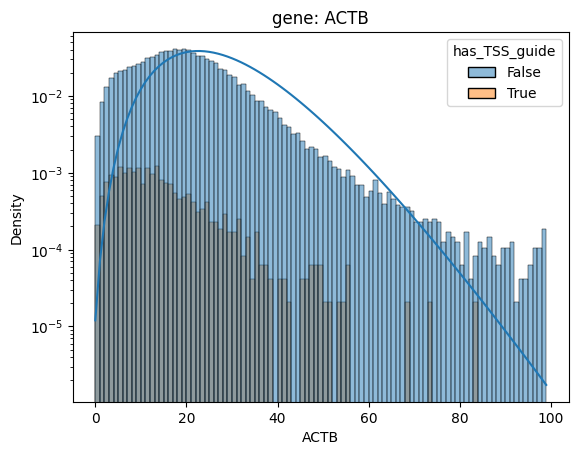

(47964,)
Index(['ACTG1_TSS|1', 'ACTG1_TSS|2'], dtype='object')
logit=2.17, total_count=2.65


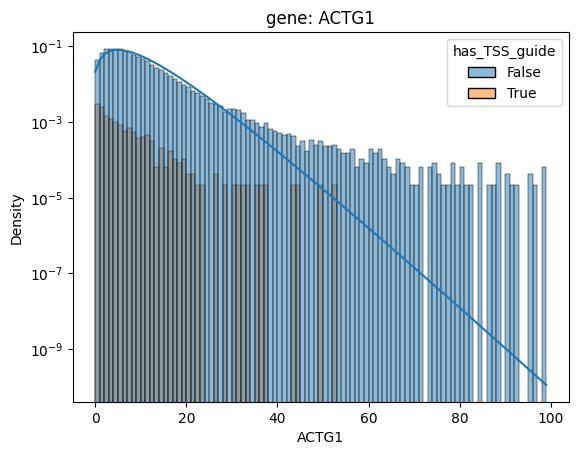

(47964,)
Index(['ACYP1_TSS|1', 'ACYP1_TSS|2'], dtype='object')
logit=0.30, total_count=7.49


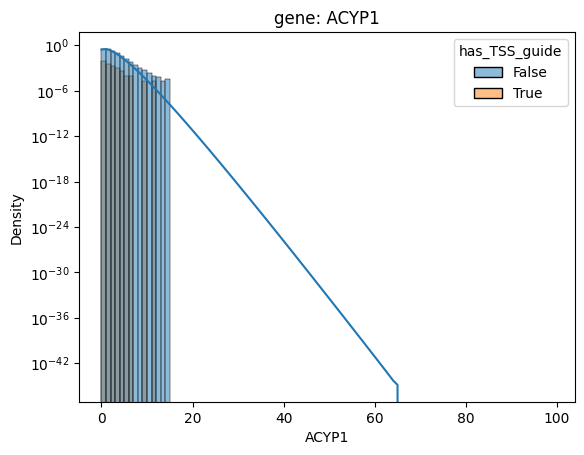

(47964,)
Index(['ADIPOR1_TSS|1', 'ADIPOR1_TSS|2'], dtype='object')
logit=0.85, total_count=13.22


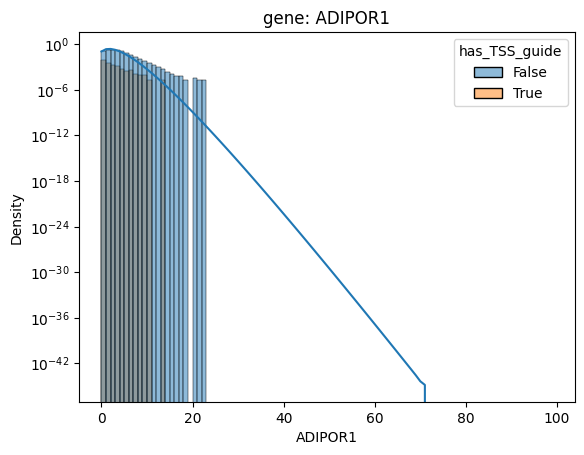

(47964,)
Index(['ALDH1A2_TSS|1', 'ALDH1A2_TSS|2'], dtype='object')
logit=0.69, total_count=2.01


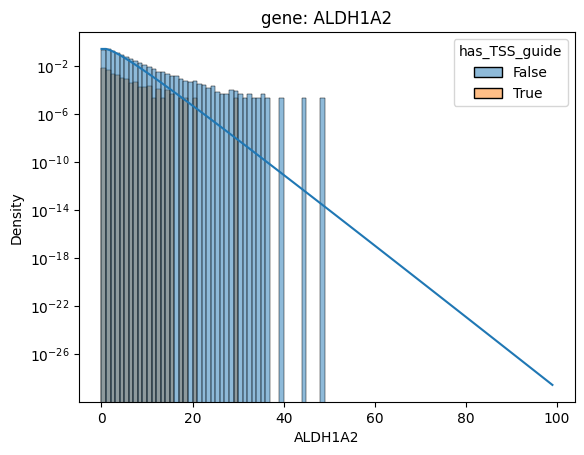

(47964,)
Index(['APEX1_TSS|1', 'APEX1_TSS|2'], dtype='object')
logit=0.83, total_count=10.80


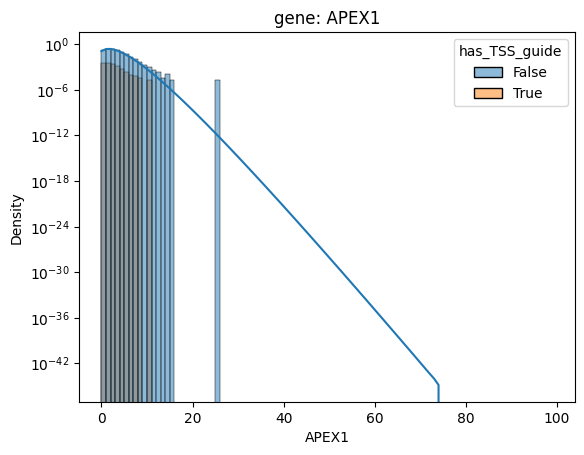

(47964,)
Index(['APLP2_TSS|1', 'APLP2_TSS|2'], dtype='object')
logit=0.83, total_count=5.83


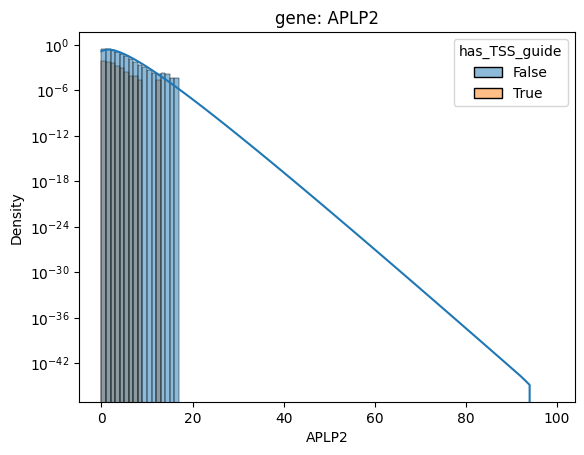

(47964,)
Index(['ARF6_TSS|1', 'ARF6_TSS|2'], dtype='object')
logit=0.74, total_count=7.74


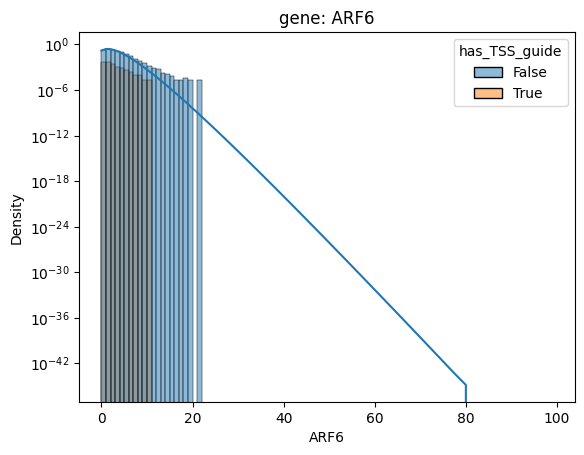

(47964,)
Index(['ARID1A_TSS|1', 'ARID1A_TSS|2'], dtype='object')
logit=-0.31, total_count=8.22


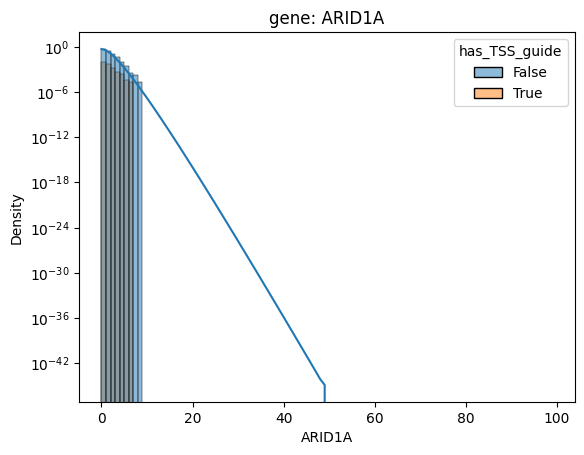

(47964,)
Index(['ARL4A_TSS|1', 'ARL4A_TSS|2'], dtype='object')
logit=1.40, total_count=6.26


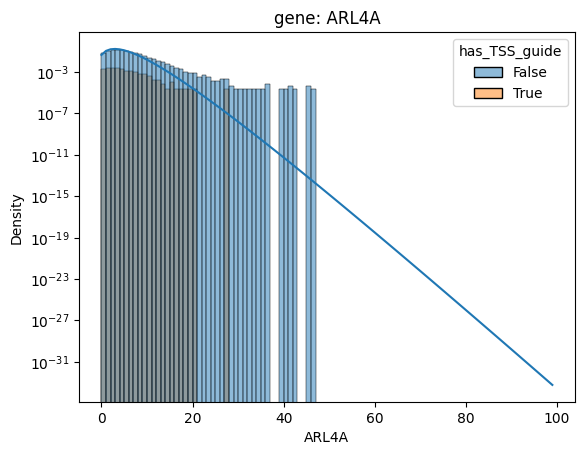

(47964,)
Index(['ARL5A_TSS|1', 'ARL5A_TSS|2'], dtype='object')
logit=-0.77, total_count=13.17


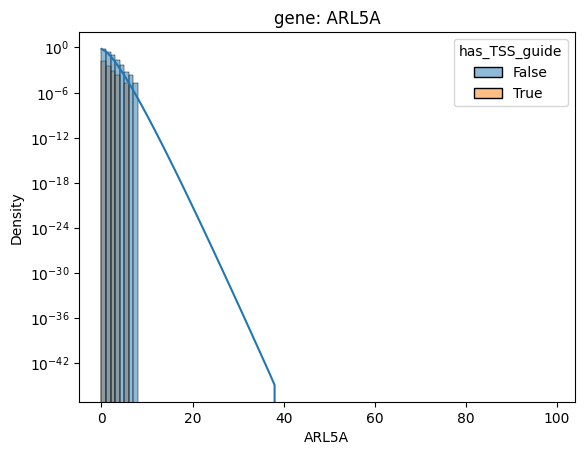

(47964,)
Index(['ARV1_TSS|1', 'ARV1_TSS|2'], dtype='object')
logit=0.01, total_count=4.89


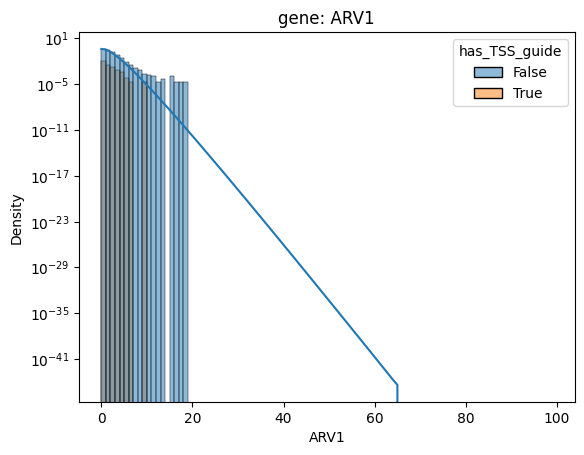

(47964,)
Index(['ASAH1_TSS|1', 'ASAH1_TSS|2'], dtype='object')
logit=0.09, total_count=2.49


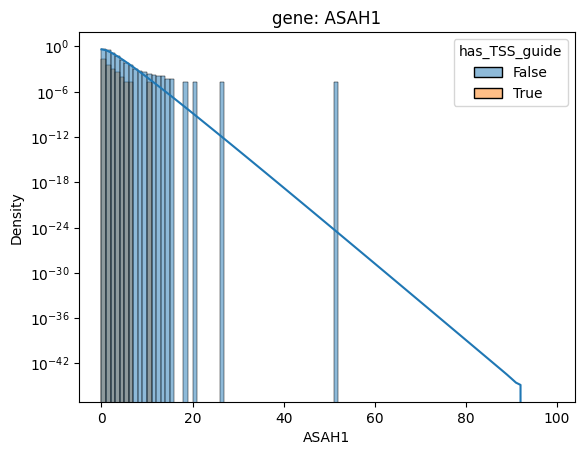

(47964,)
Index(['ATP6V1F_TSS|1', 'ATP6V1F_TSS|2'], dtype='object')
logit=2.42, total_count=11.29


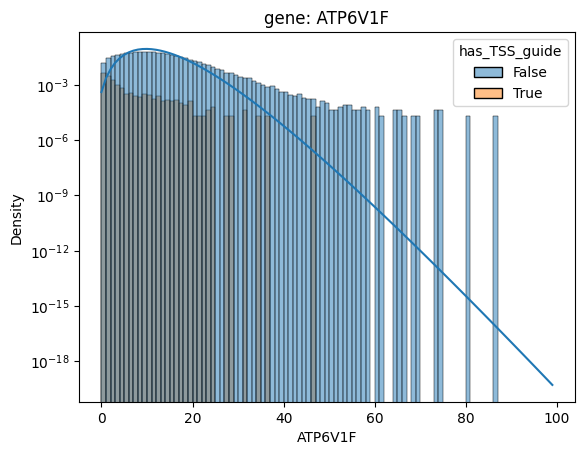

(47964,)
Index(['AZIN1_TSS|1', 'AZIN1_TSS|2'], dtype='object')
logit=0.06, total_count=11.45


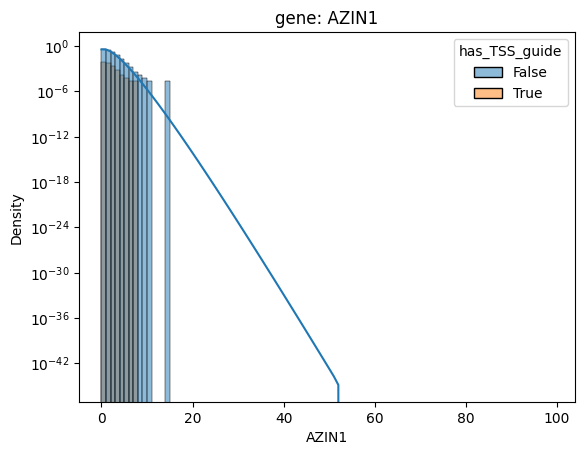

(47964,)
Index(['BANF1_TSS|1', 'BANF1_TSS|2'], dtype='object')
logit=1.43, total_count=18.50


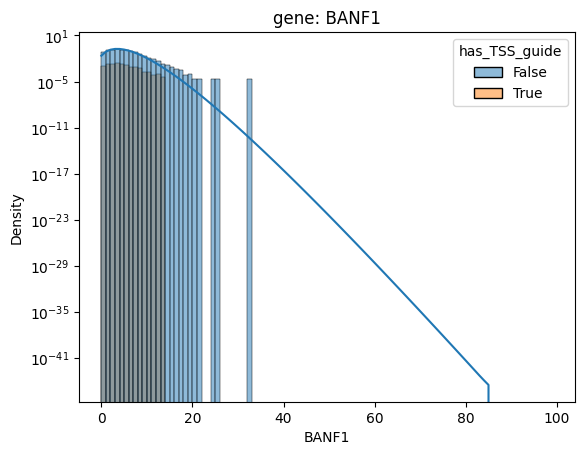

(47964,)
Index(['BCAP29_TSS|1', 'BCAP29_TSS|2'], dtype='object')
logit=0.37, total_count=11.57


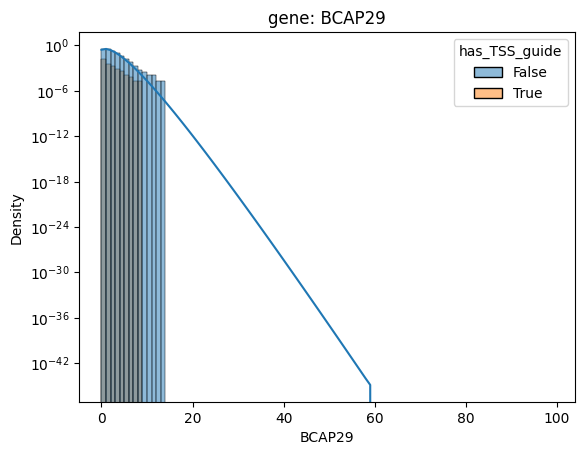

(47964,)
Index(['BEX4_TSS|1', 'BEX4_TSS|2'], dtype='object')
logit=-0.60, total_count=0.76


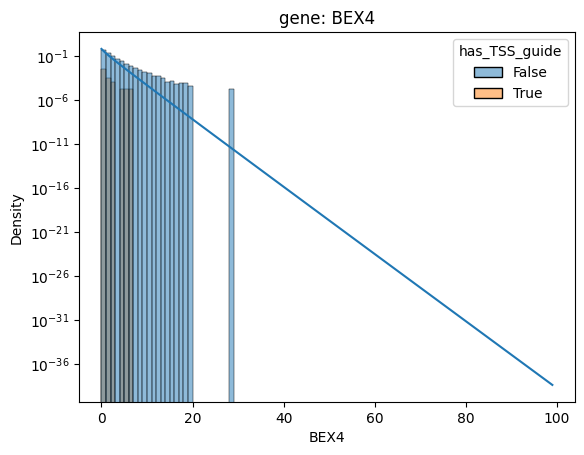

(47964,)
Index(['BLVRB_TSS|1', 'BLVRB_TSS|2'], dtype='object')
logit=2.37, total_count=3.26


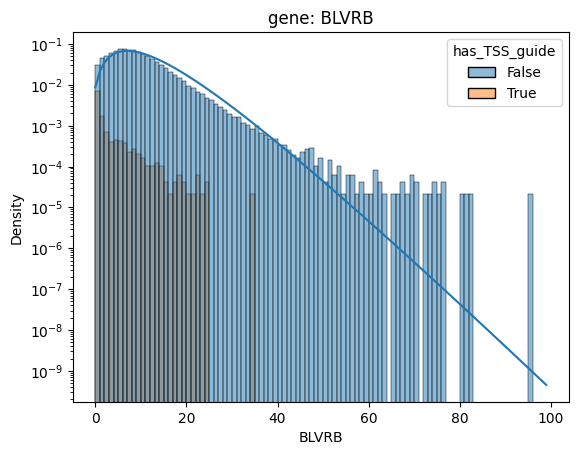

(47964,)
Index(['BRI3_TSS|1', 'BRI3_TSS|2'], dtype='object')
logit=1.17, total_count=8.09


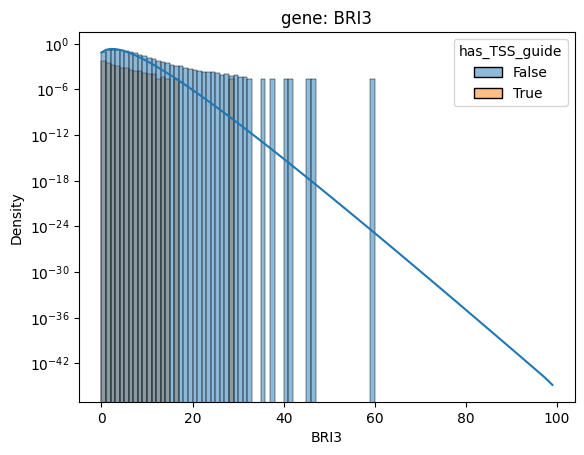

(47964,)
Index(['BRIX1_TSS|1', 'BRIX1_TSS|2'], dtype='object')
logit=1.08, total_count=4.12


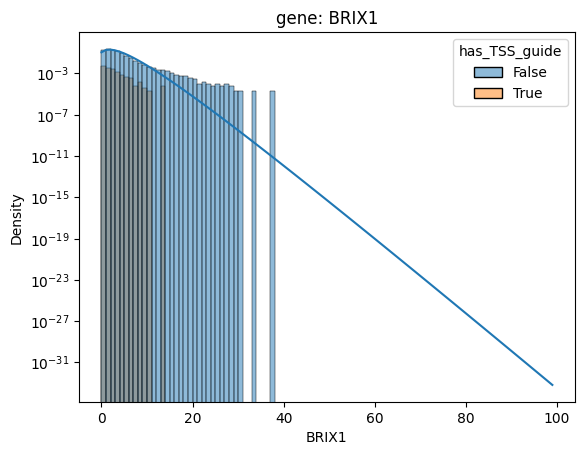

(47964,)
Index(['BROX_TSS|1', 'BROX_TSS|2'], dtype='object')
logit=0.13, total_count=5.58


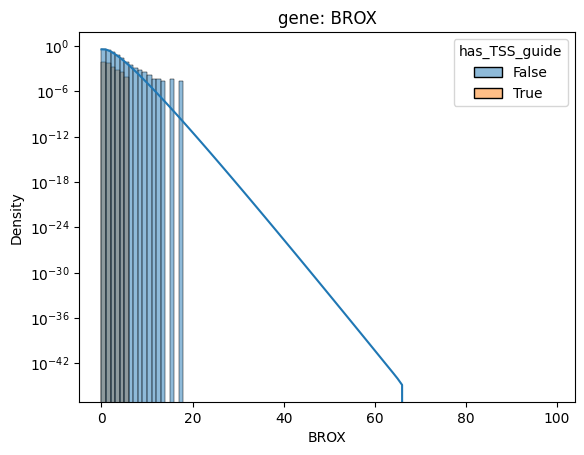

(47964,)
Index(['BTF3_TSS|1', 'BTF3_TSS|2'], dtype='object')
logit=3.18, total_count=24.28


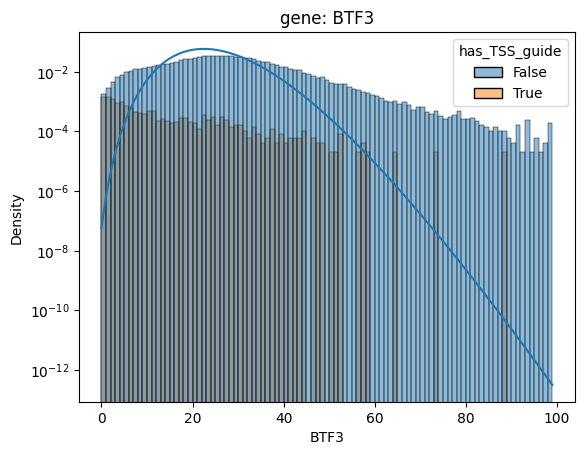

(47964,)
Index(['BTF3L4_TSS|1', 'BTF3L4_TSS|2'], dtype='object')
logit=0.54, total_count=14.32


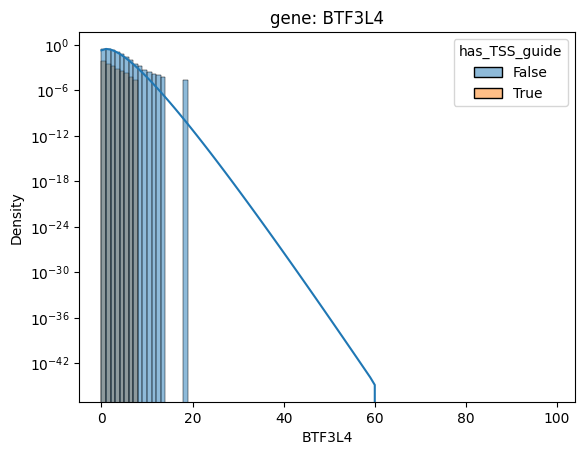

(47964,)
Index(['BUB3_TSS|1', 'BUB3_TSS|2'], dtype='object')
logit=0.96, total_count=9.95


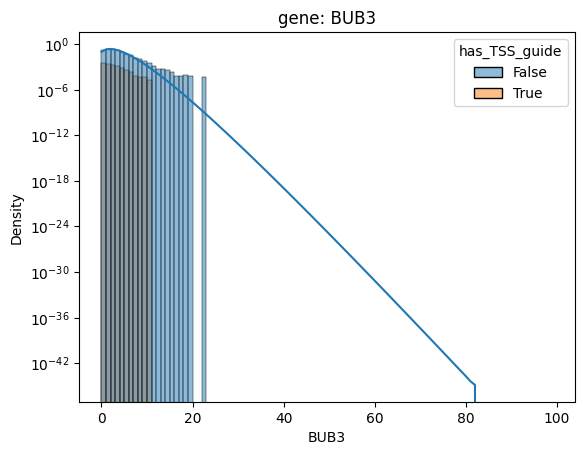

(47964,)
Index(['C16orf91_TSS|1', 'C16orf91_TSS|2'], dtype='object')
logit=0.63, total_count=10.26


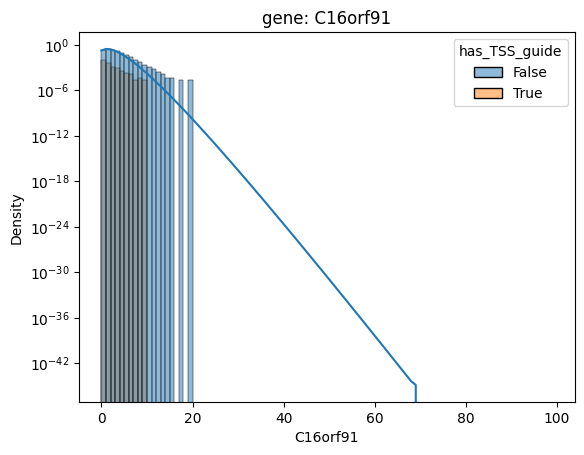

(47964,)
Index(['C1D_TSS|1', 'C1D_TSS|2'], dtype='object')
logit=0.65, total_count=10.80


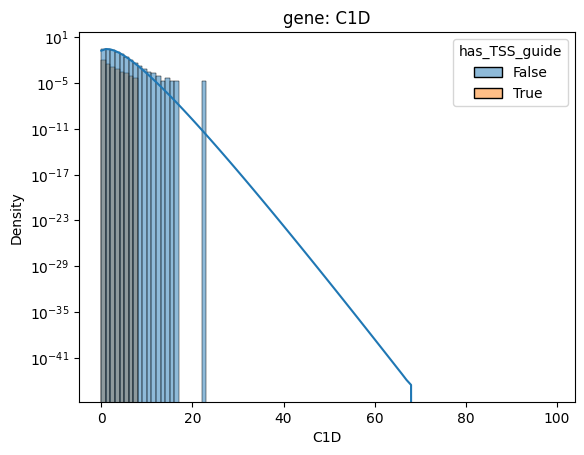

(47964,)
Index(['C1orf52_TSS|1', 'C1orf52_TSS|2'], dtype='object')
logit=-0.08, total_count=10.05


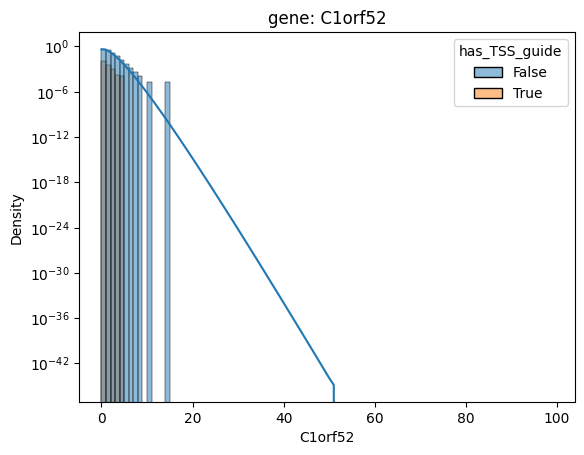

(47964,)
Index(['CALM3_TSS|1', 'CALM3_TSS|2'], dtype='object')
logit=1.26, total_count=16.23


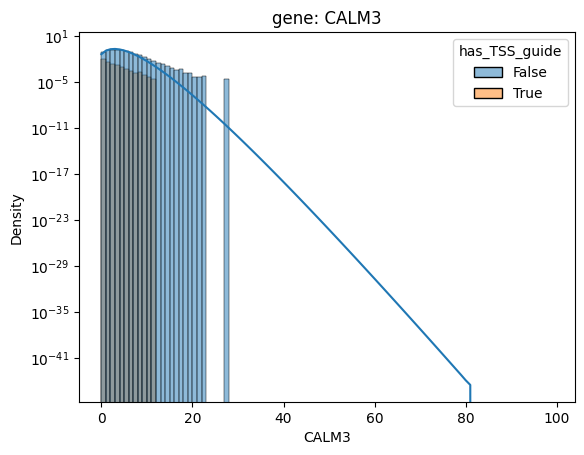

(47964,)
Index(['CAP1_TSS|1', 'CAP1_TSS|2'], dtype='object')
logit=1.21, total_count=6.07


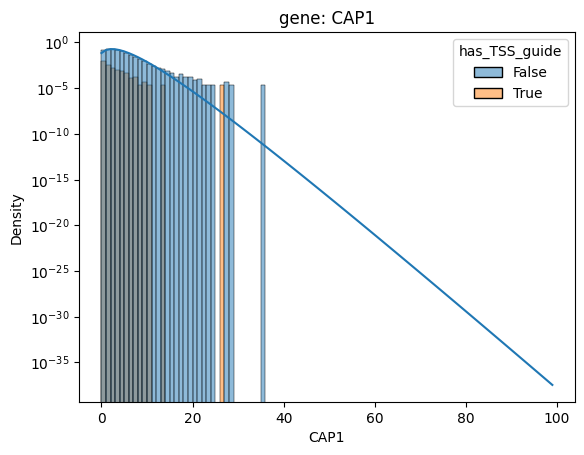

(47964,)
Index(['CAPZA2_TSS|1', 'CAPZA2_TSS|2'], dtype='object')
logit=1.11, total_count=10.06


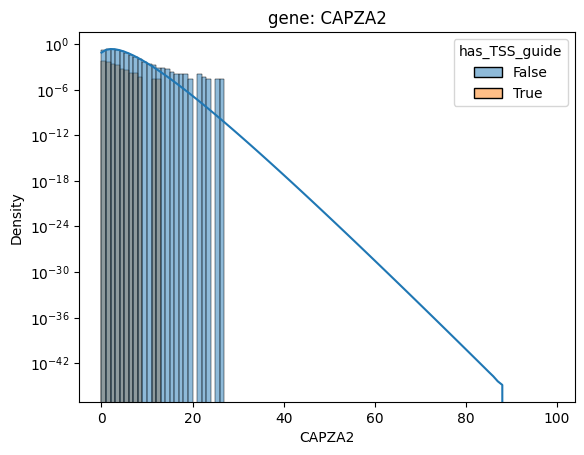

(47964,)
Index(['CCDC58_TSS|1', 'CCDC58_TSS|2'], dtype='object')
logit=0.37, total_count=6.24


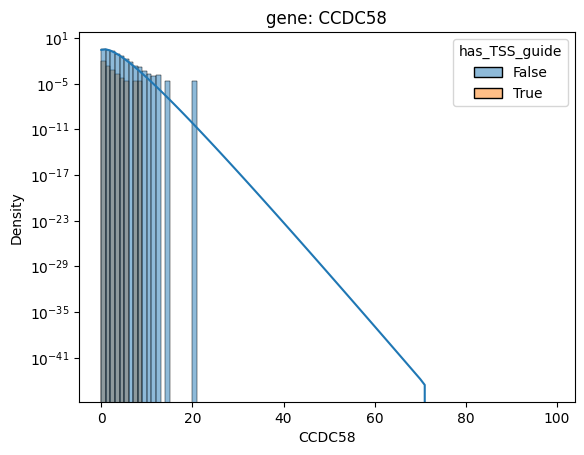

(47964,)
Index(['CCDC71L_TSS|1', 'CCDC71L_TSS|2'], dtype='object')
logit=-0.10, total_count=3.30


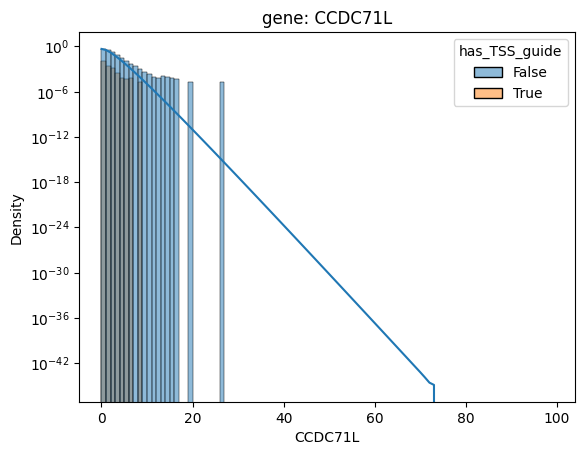

(47964,)
Index(['CCDC86_TSS|1', 'CCDC86_TSS|2'], dtype='object')
logit=0.87, total_count=6.55


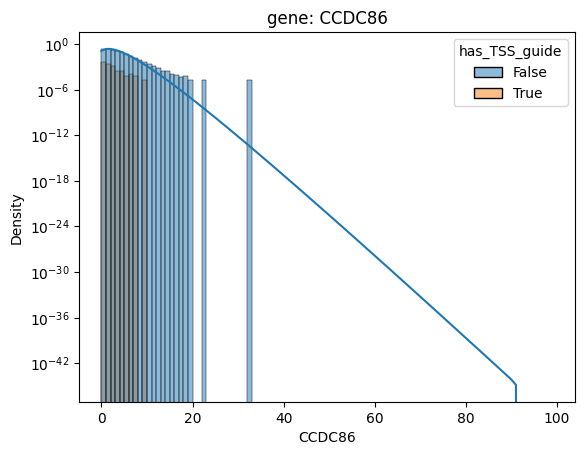

(47964,)
Index(['CCND2_TSS|1', 'CCND2_TSS|2'], dtype='object')
logit=0.22, total_count=4.72


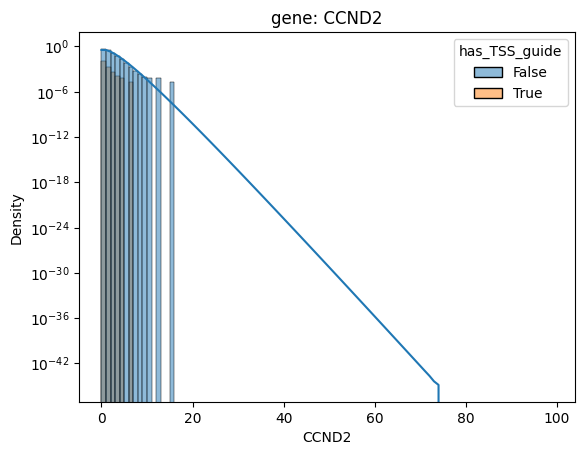

(47964,)
Index(['CCNDBP1_TSS|1', 'CCNDBP1_TSS|2'], dtype='object')
logit=-0.19, total_count=3.93


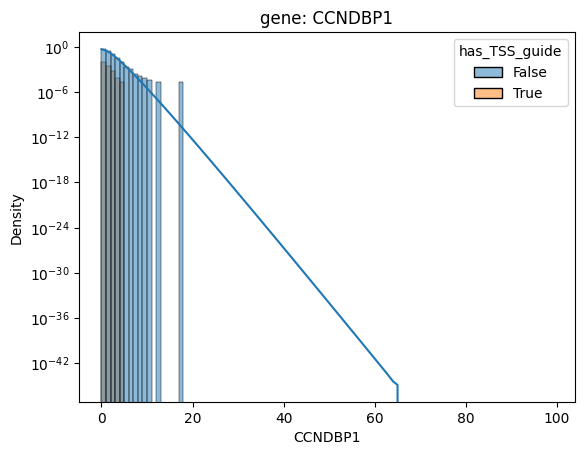

(47964,)
Index(['CCT5_TSS|1', 'CCT5_TSS|2'], dtype='object')
logit=2.22, total_count=6.60


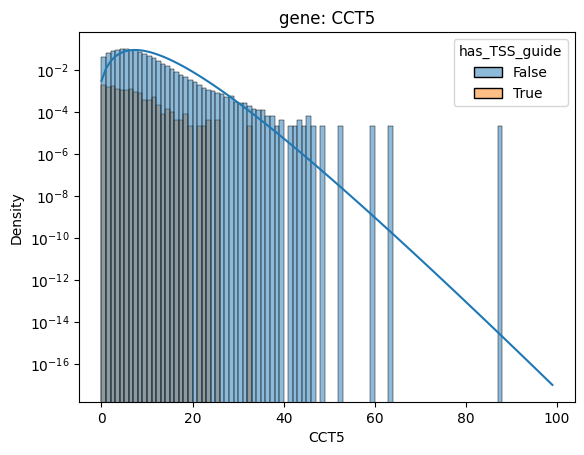

(47964,)
Index(['CD46_TSS|1', 'CD46_TSS|2'], dtype='object')
logit=-0.16, total_count=6.32


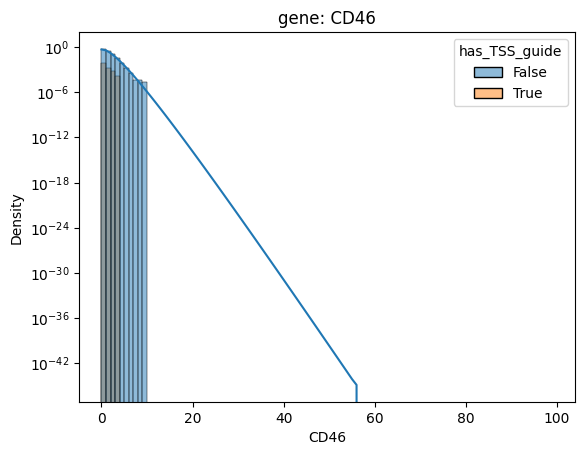

(47964,)
Index(['CD47_TSS|1', 'CD47_TSS|2'], dtype='object')
logit=0.41, total_count=4.48


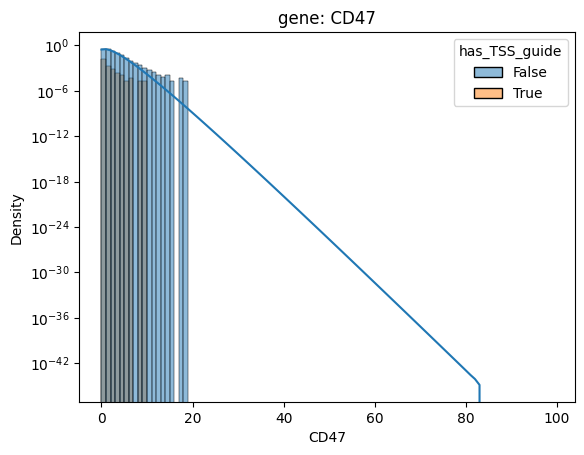

(47964,)
Index(['CEBPB_TSS|1', 'CEBPB_TSS|2'], dtype='object')
logit=-0.10, total_count=1.67


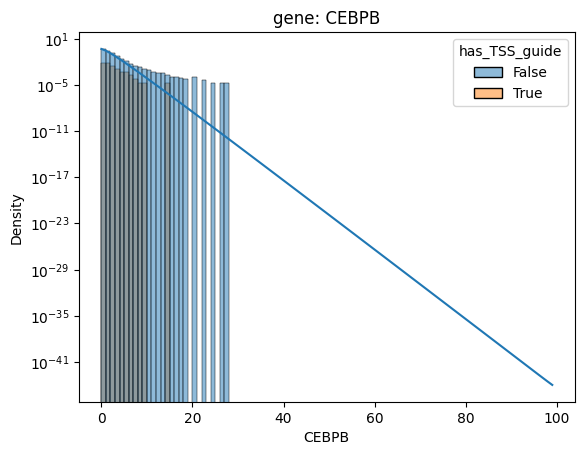

(47964,)
Index(['CENPK_TSS|1', 'CENPK_TSS|2'], dtype='object')
logit=0.06, total_count=9.08


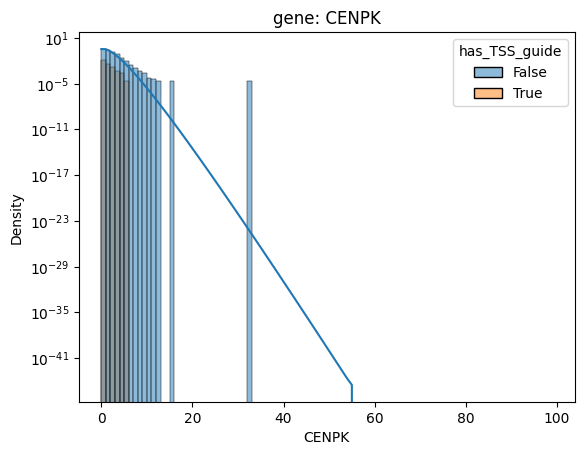

(47964,)
Index(['CENPW_TSS|1', 'CENPW_TSS|2'], dtype='object')
logit=1.49, total_count=14.91


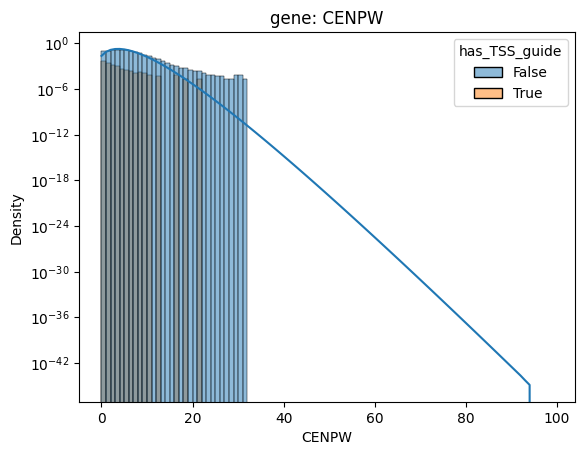

(47964,)
Index(['CERS2_TSS|1', 'CERS2_TSS|2'], dtype='object')
logit=-0.19, total_count=13.15


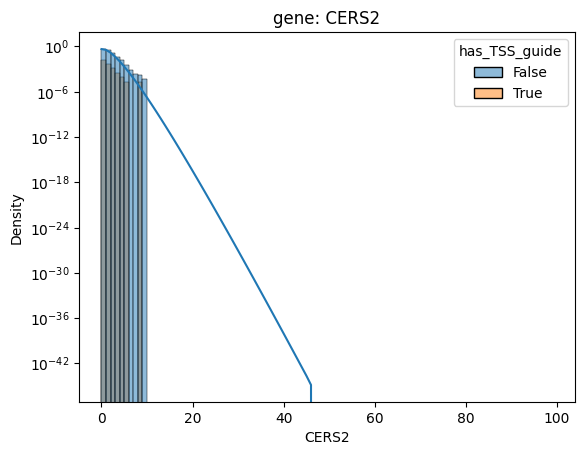

(47964,)
Index(['CHCHD10_TSS|1', 'CHCHD10_TSS|2'], dtype='object')
logit=2.63, total_count=11.26


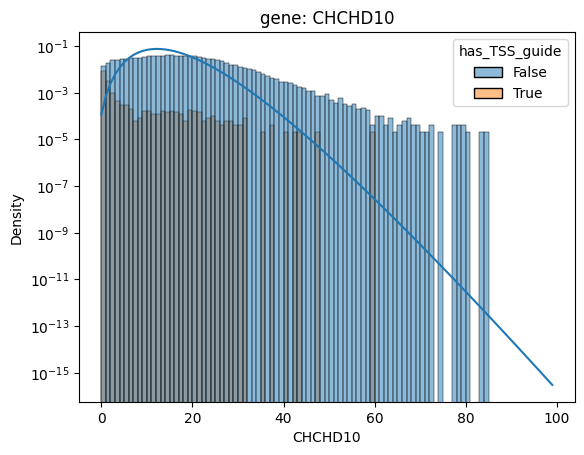

(47964,)
Index(['CHCHD3_TSS|1', 'CHCHD3_TSS|2'], dtype='object')
logit=1.50, total_count=13.68


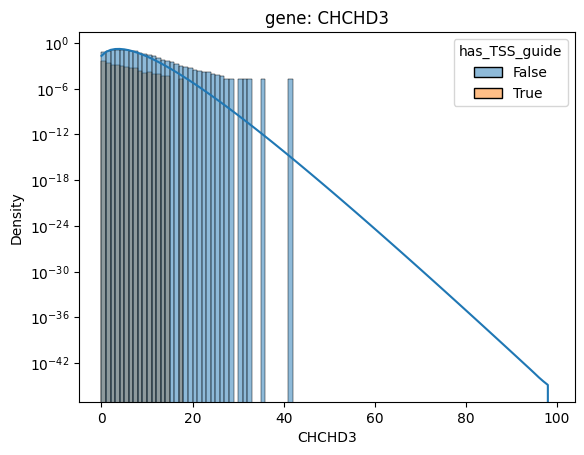

(47964,)
Index(['CHMP1B_TSS|1', 'CHMP1B_TSS|2'], dtype='object')
logit=-0.56, total_count=4.73


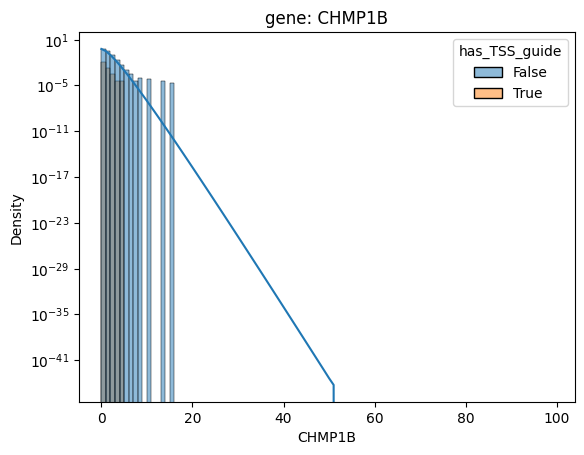

(47964,)
Index(['CHPT1_TSS|1', 'CHPT1_TSS|2'], dtype='object')
logit=1.14, total_count=11.69


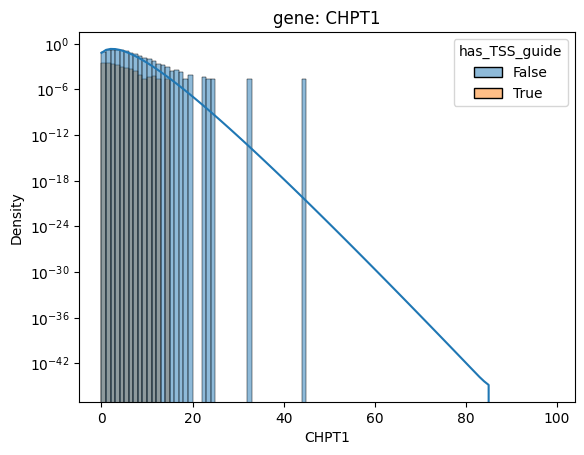

(47964,)
Index(['CHRAC1_TSS|1', 'CHRAC1_TSS|2'], dtype='object')
logit=0.46, total_count=12.16


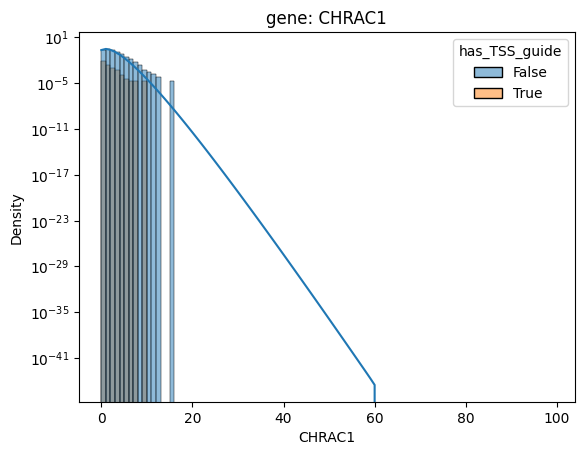

(47964,)
Index(['CITED2_TSS|1', 'CITED2_TSS|2'], dtype='object')
logit=-0.36, total_count=1.07


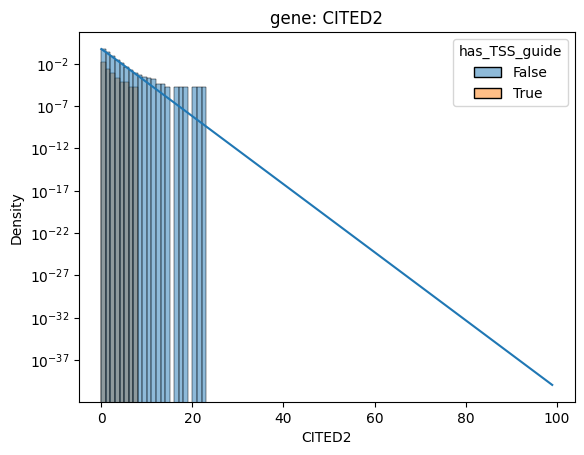

(47964,)
Index(['CKB_TSS|1', 'CKB_TSS|2'], dtype='object')
logit=2.11, total_count=3.92


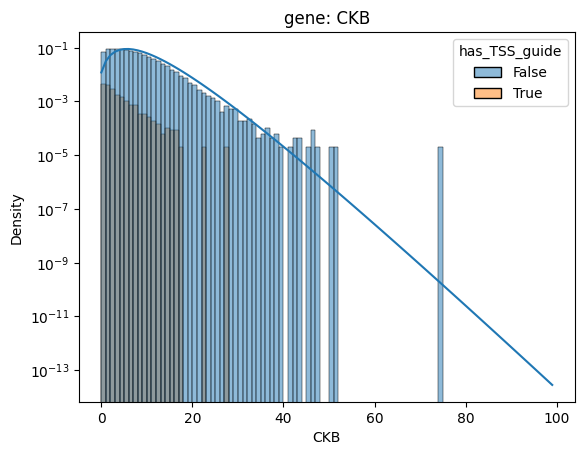

In [ ]:
for sg in selected_genes:
    plot_gene_distribution(model.module.guide.median(), gene_name=sg, log_y_scale=True)

(47964,)
Index(['ACTB_TSS|1', 'ACTB_TSS|2'], dtype='object')


logit=3.28, total_count=7.44


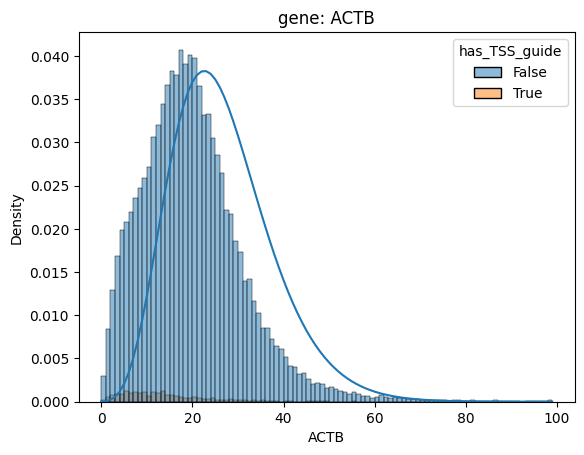

(47964,)
Index(['ACTG1_TSS|1', 'ACTG1_TSS|2'], dtype='object')
logit=2.17, total_count=2.65


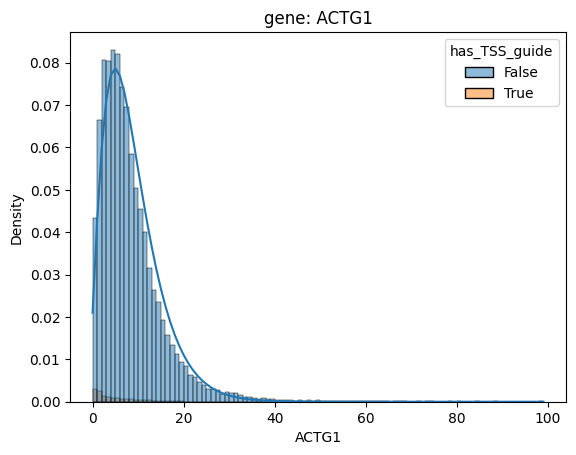

(47964,)
Index(['ACYP1_TSS|1', 'ACYP1_TSS|2'], dtype='object')
logit=0.30, total_count=7.49


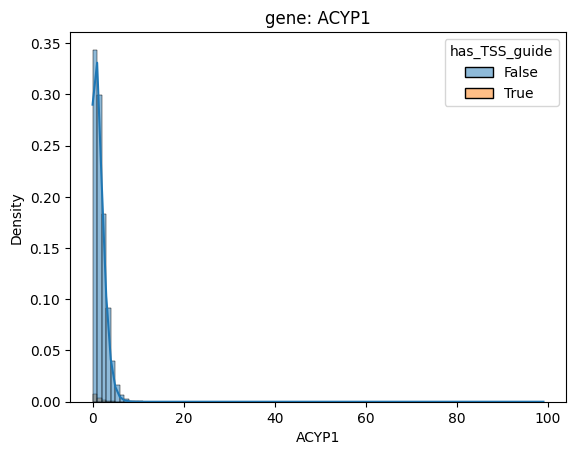

(47964,)
Index(['ADIPOR1_TSS|1', 'ADIPOR1_TSS|2'], dtype='object')
logit=0.85, total_count=13.22


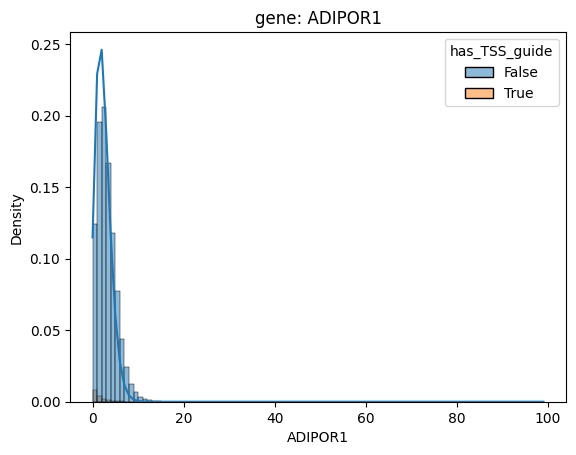

(47964,)
Index(['ALDH1A2_TSS|1', 'ALDH1A2_TSS|2'], dtype='object')
logit=0.69, total_count=2.01


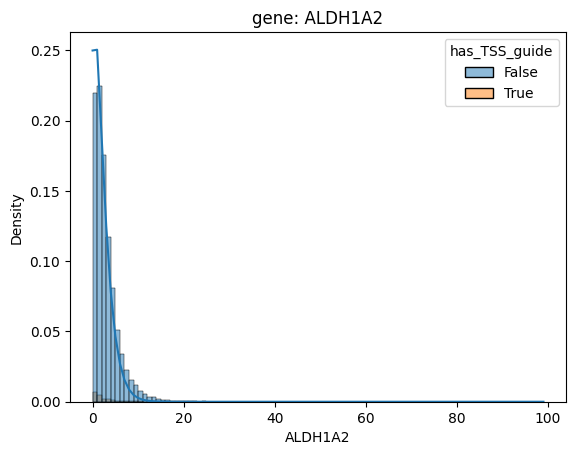

(47964,)
Index(['APEX1_TSS|1', 'APEX1_TSS|2'], dtype='object')
logit=0.83, total_count=10.80


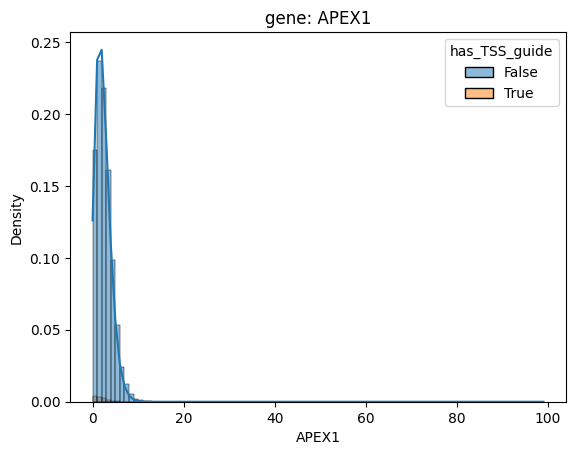

(47964,)
Index(['APLP2_TSS|1', 'APLP2_TSS|2'], dtype='object')
logit=0.83, total_count=5.83


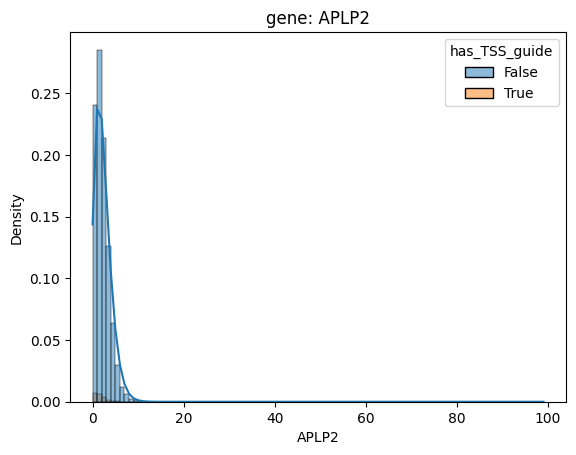

(47964,)
Index(['ARF6_TSS|1', 'ARF6_TSS|2'], dtype='object')
logit=0.74, total_count=7.74


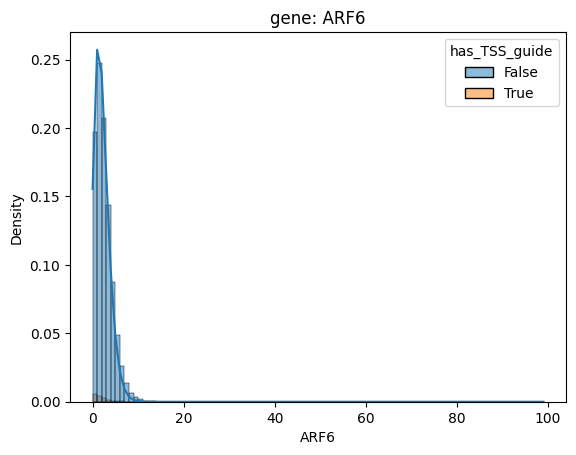

(47964,)
Index(['ARID1A_TSS|1', 'ARID1A_TSS|2'], dtype='object')
logit=-0.31, total_count=8.22


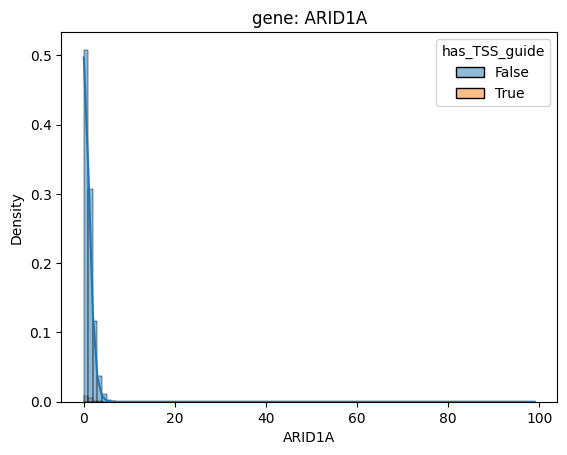

(47964,)
Index(['ARL4A_TSS|1', 'ARL4A_TSS|2'], dtype='object')
logit=1.40, total_count=6.26


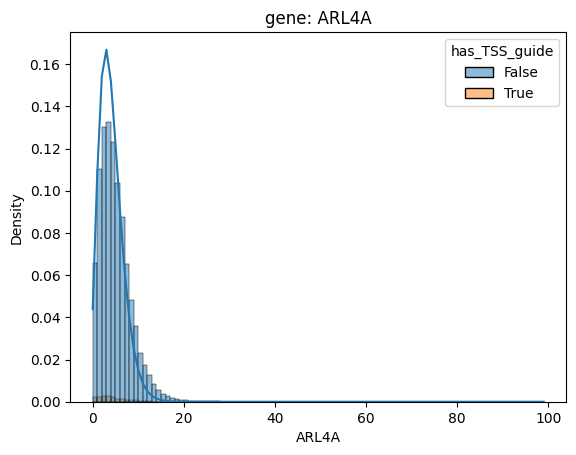

(47964,)
Index(['ARL5A_TSS|1', 'ARL5A_TSS|2'], dtype='object')
logit=-0.77, total_count=13.17


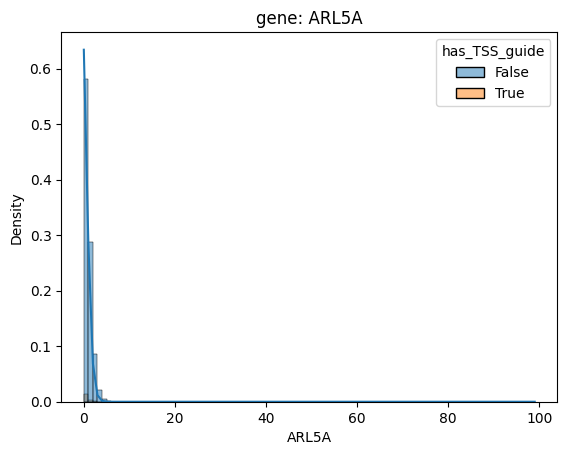

(47964,)
Index(['ARV1_TSS|1', 'ARV1_TSS|2'], dtype='object')
logit=0.01, total_count=4.89


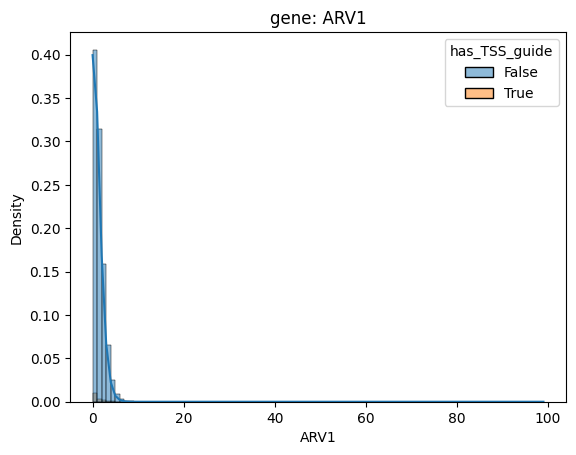

(47964,)
Index(['ASAH1_TSS|1', 'ASAH1_TSS|2'], dtype='object')
logit=0.09, total_count=2.49


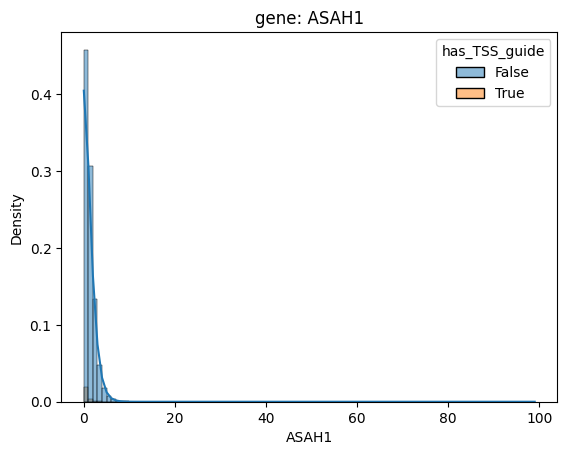

(47964,)
Index(['ATP6V1F_TSS|1', 'ATP6V1F_TSS|2'], dtype='object')
logit=2.42, total_count=11.29


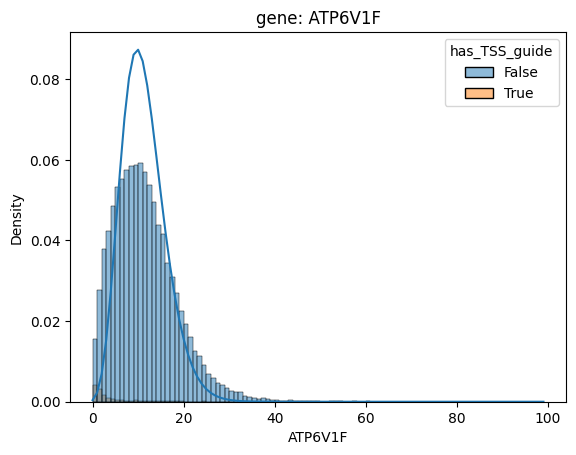

(47964,)
Index(['AZIN1_TSS|1', 'AZIN1_TSS|2'], dtype='object')
logit=0.06, total_count=11.45


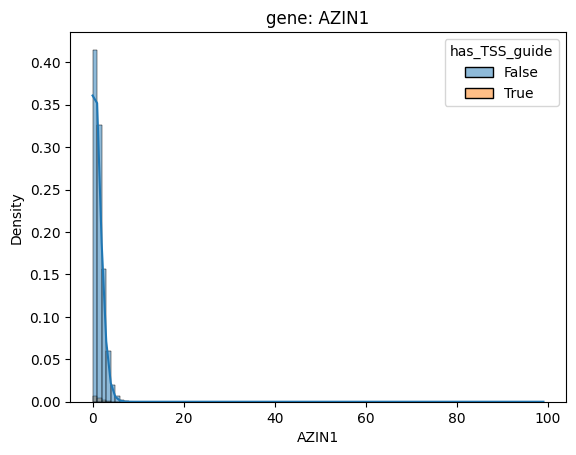

(47964,)
Index(['BANF1_TSS|1', 'BANF1_TSS|2'], dtype='object')
logit=1.43, total_count=18.50


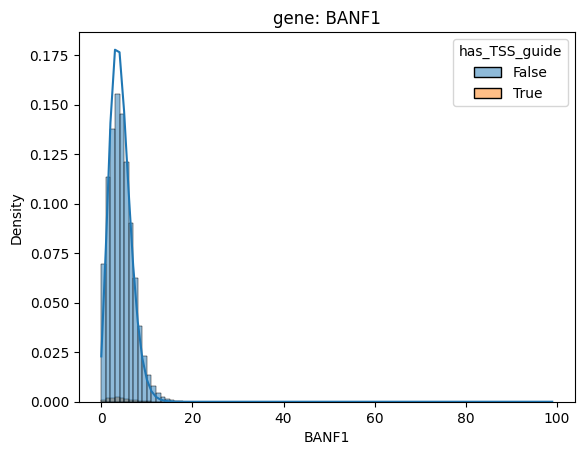

(47964,)
Index(['BCAP29_TSS|1', 'BCAP29_TSS|2'], dtype='object')
logit=0.37, total_count=11.57


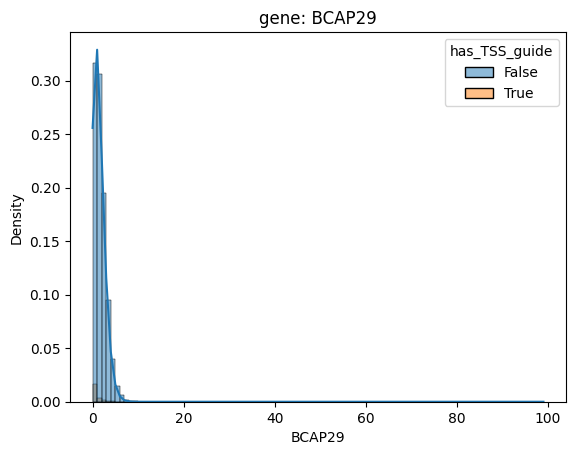

(47964,)
Index(['BEX4_TSS|1', 'BEX4_TSS|2'], dtype='object')
logit=-0.60, total_count=0.76


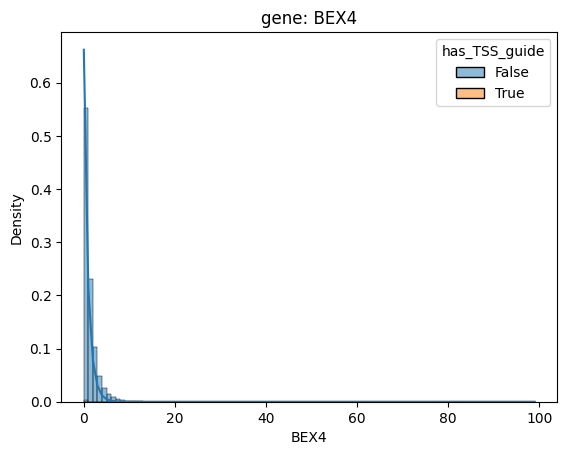

(47964,)
Index(['BLVRB_TSS|1', 'BLVRB_TSS|2'], dtype='object')
logit=2.37, total_count=3.26


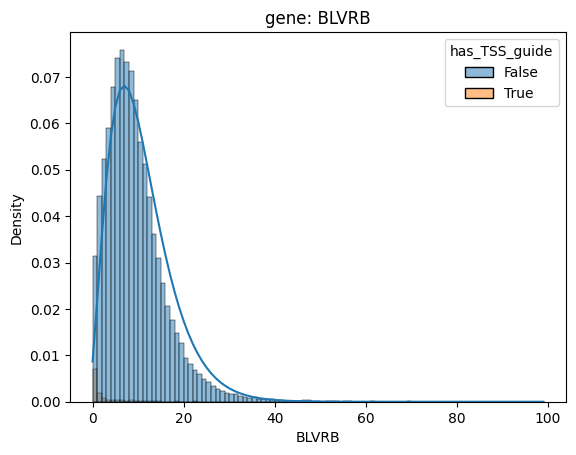

(47964,)
Index(['BRI3_TSS|1', 'BRI3_TSS|2'], dtype='object')
logit=1.17, total_count=8.09


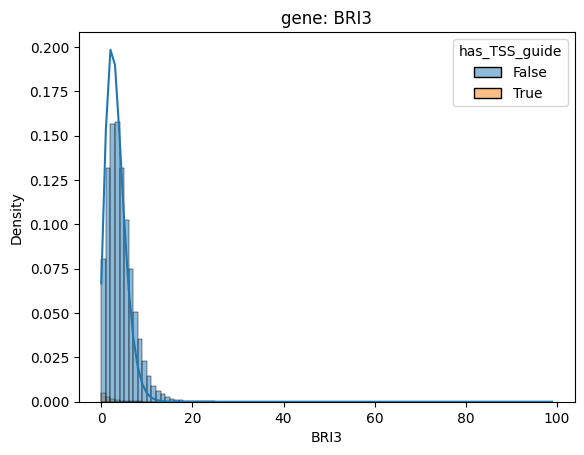

(47964,)
Index(['BRIX1_TSS|1', 'BRIX1_TSS|2'], dtype='object')
logit=1.08, total_count=4.12


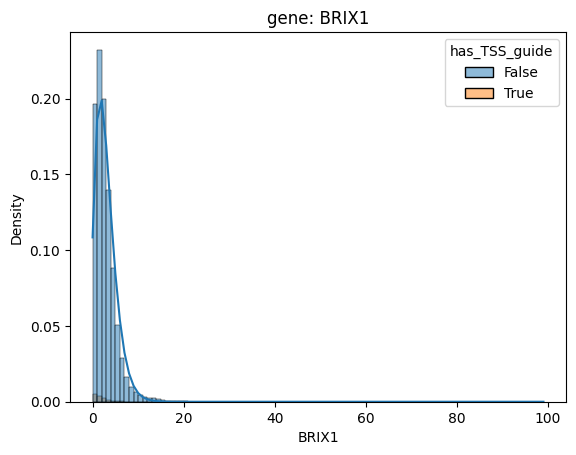

(47964,)
Index(['BROX_TSS|1', 'BROX_TSS|2'], dtype='object')
logit=0.13, total_count=5.58


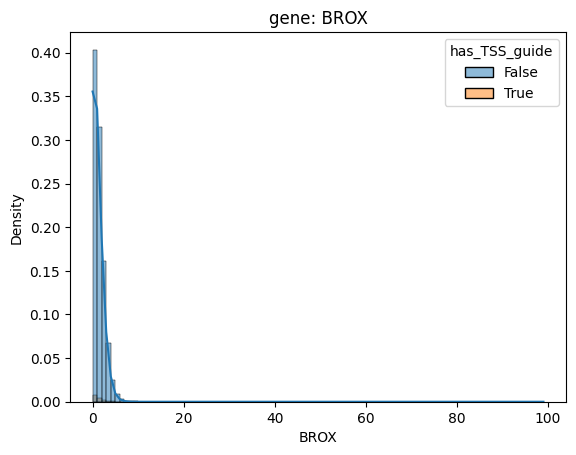

(47964,)
Index(['BTF3_TSS|1', 'BTF3_TSS|2'], dtype='object')
logit=3.18, total_count=24.28


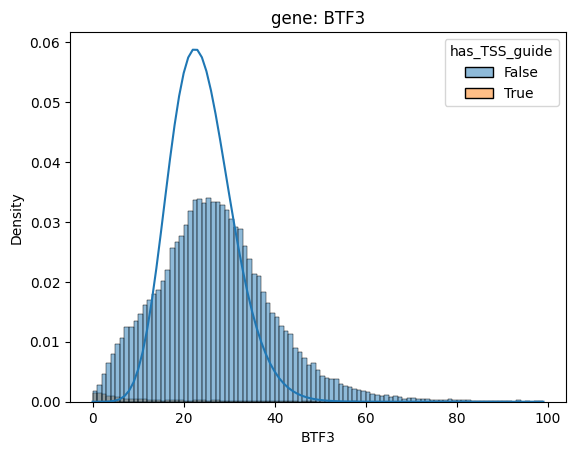

(47964,)
Index(['BTF3L4_TSS|1', 'BTF3L4_TSS|2'], dtype='object')
logit=0.54, total_count=14.32


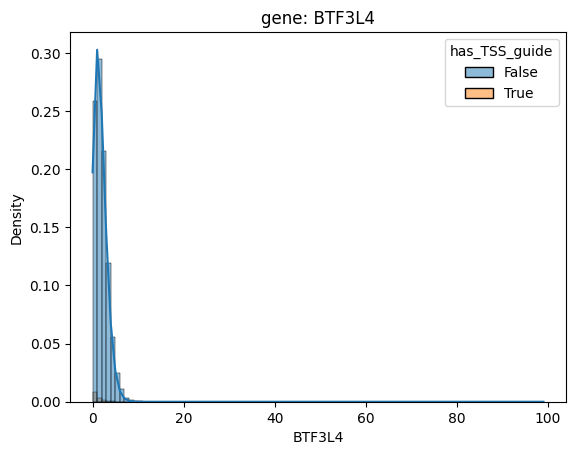

(47964,)
Index(['BUB3_TSS|1', 'BUB3_TSS|2'], dtype='object')
logit=0.96, total_count=9.95


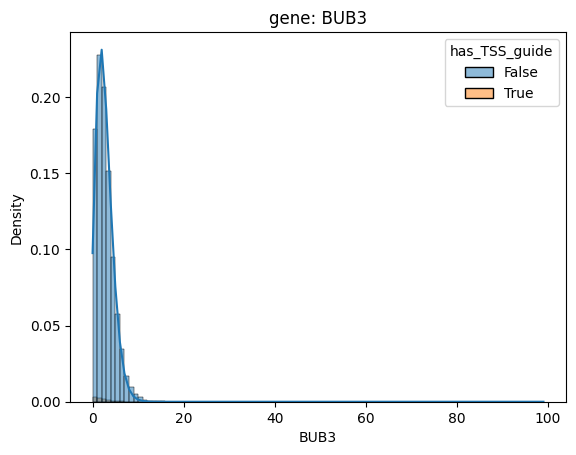

(47964,)
Index(['C16orf91_TSS|1', 'C16orf91_TSS|2'], dtype='object')
logit=0.63, total_count=10.26


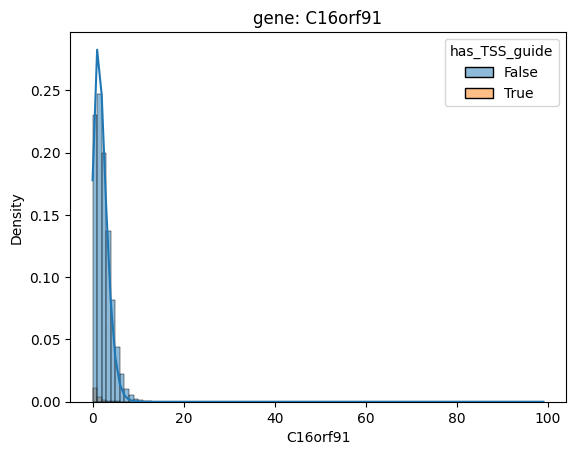

(47964,)
Index(['C1D_TSS|1', 'C1D_TSS|2'], dtype='object')
logit=0.65, total_count=10.80


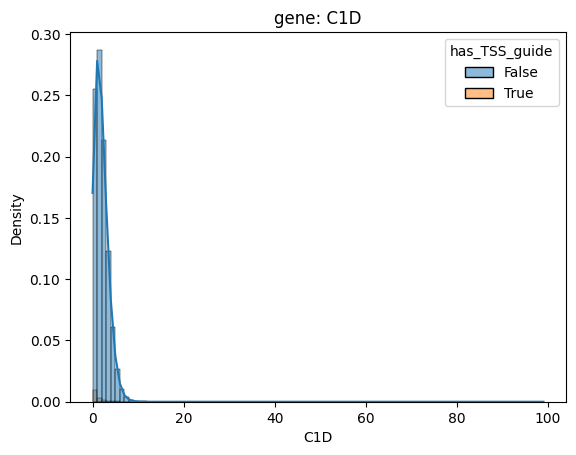

(47964,)
Index(['C1orf52_TSS|1', 'C1orf52_TSS|2'], dtype='object')
logit=-0.08, total_count=10.05


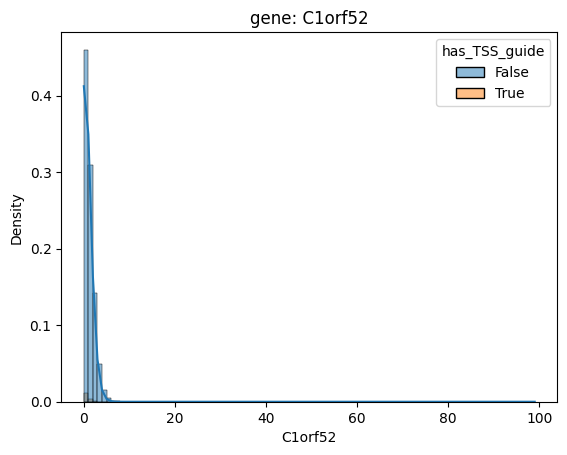

(47964,)
Index(['CALM3_TSS|1', 'CALM3_TSS|2'], dtype='object')
logit=1.26, total_count=16.23


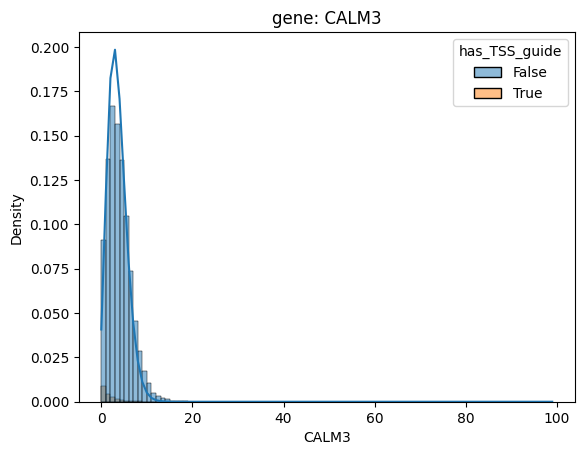

(47964,)
Index(['CAP1_TSS|1', 'CAP1_TSS|2'], dtype='object')
logit=1.21, total_count=6.07


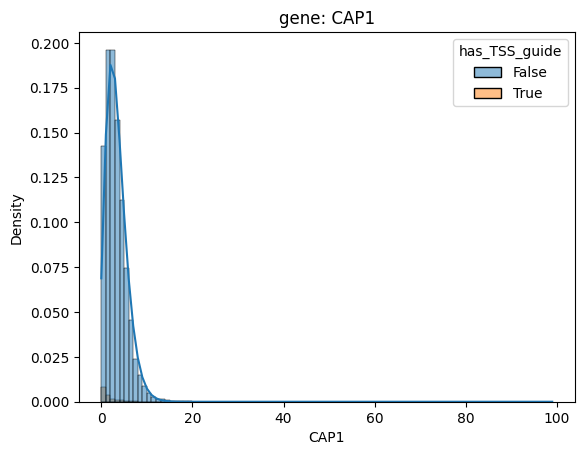

(47964,)
Index(['CAPZA2_TSS|1', 'CAPZA2_TSS|2'], dtype='object')
logit=1.11, total_count=10.06


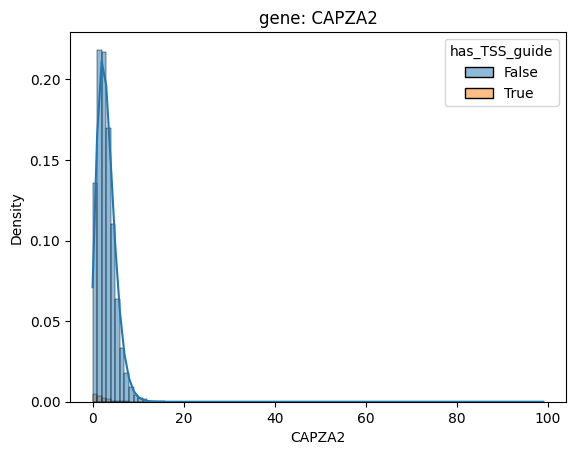

(47964,)
Index(['CCDC58_TSS|1', 'CCDC58_TSS|2'], dtype='object')
logit=0.37, total_count=6.24


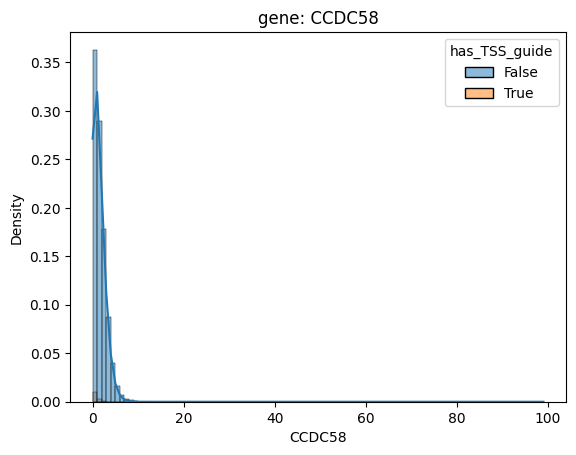

(47964,)
Index(['CCDC71L_TSS|1', 'CCDC71L_TSS|2'], dtype='object')
logit=-0.10, total_count=3.30


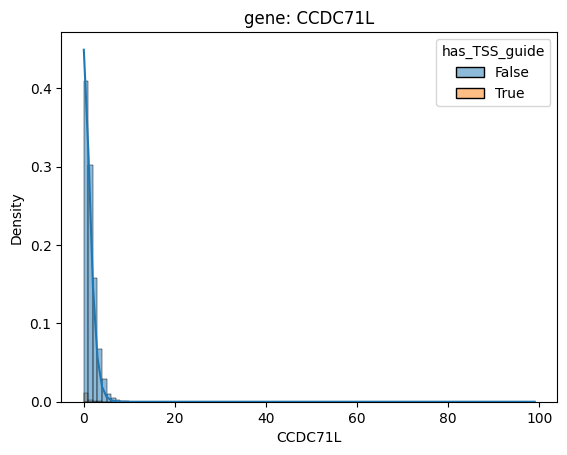

(47964,)
Index(['CCDC86_TSS|1', 'CCDC86_TSS|2'], dtype='object')
logit=0.87, total_count=6.55


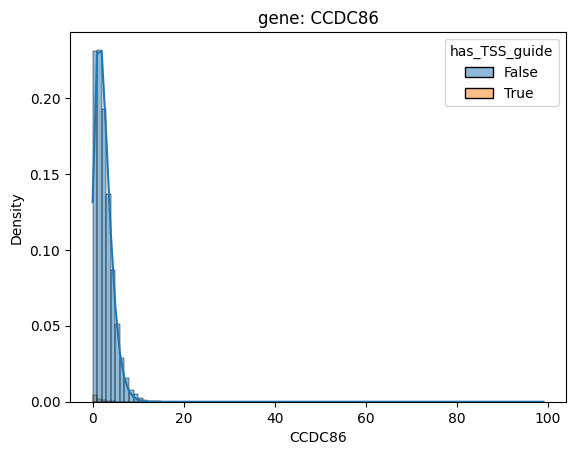

(47964,)
Index(['CCND2_TSS|1', 'CCND2_TSS|2'], dtype='object')
logit=0.22, total_count=4.72


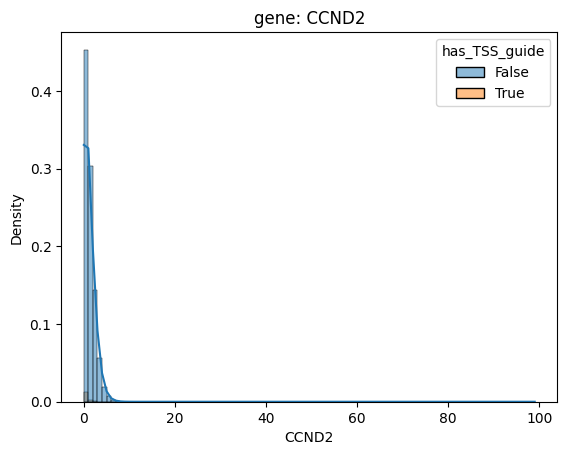

(47964,)
Index(['CCNDBP1_TSS|1', 'CCNDBP1_TSS|2'], dtype='object')
logit=-0.19, total_count=3.93


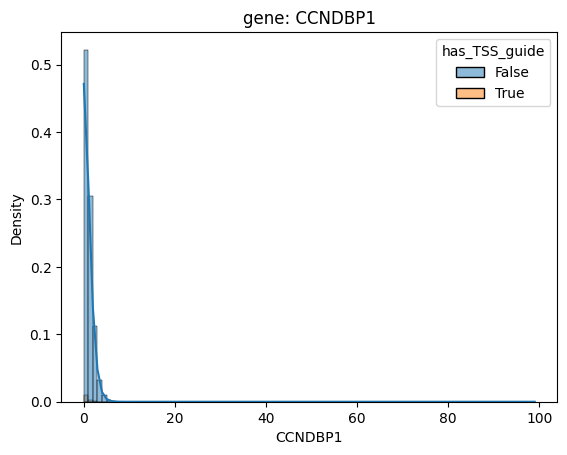

(47964,)
Index(['CCT5_TSS|1', 'CCT5_TSS|2'], dtype='object')
logit=2.22, total_count=6.60


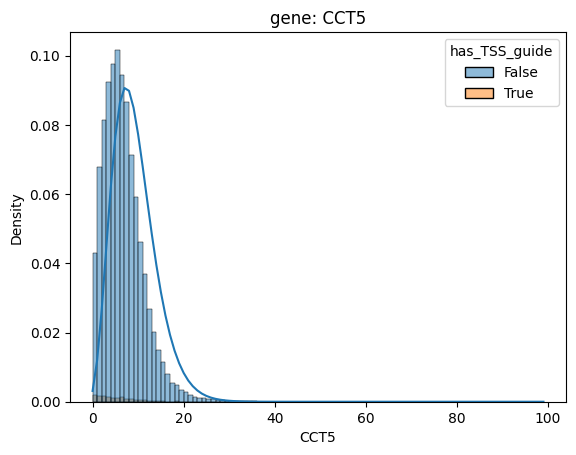

(47964,)
Index(['CD46_TSS|1', 'CD46_TSS|2'], dtype='object')
logit=-0.16, total_count=6.32


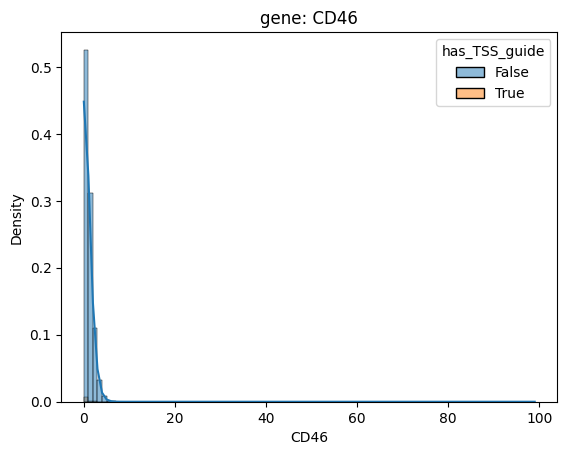

(47964,)
Index(['CD47_TSS|1', 'CD47_TSS|2'], dtype='object')
logit=0.41, total_count=4.48


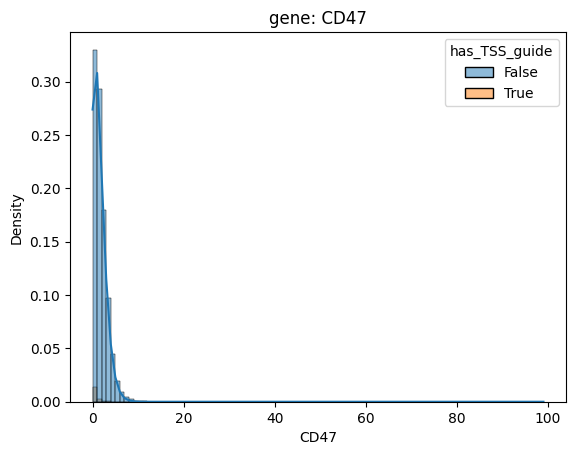

(47964,)
Index(['CEBPB_TSS|1', 'CEBPB_TSS|2'], dtype='object')
logit=-0.10, total_count=1.67


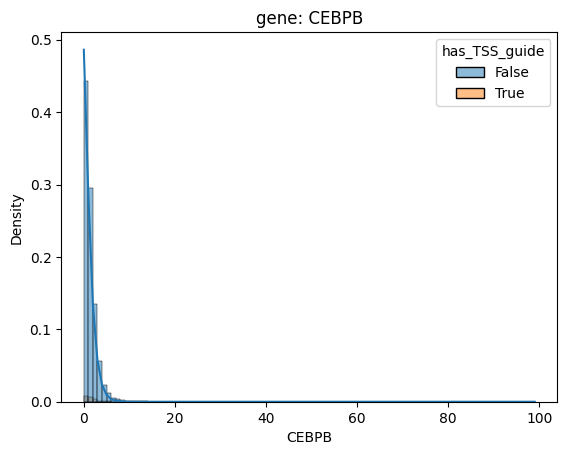

(47964,)
Index(['CENPK_TSS|1', 'CENPK_TSS|2'], dtype='object')
logit=0.06, total_count=9.08


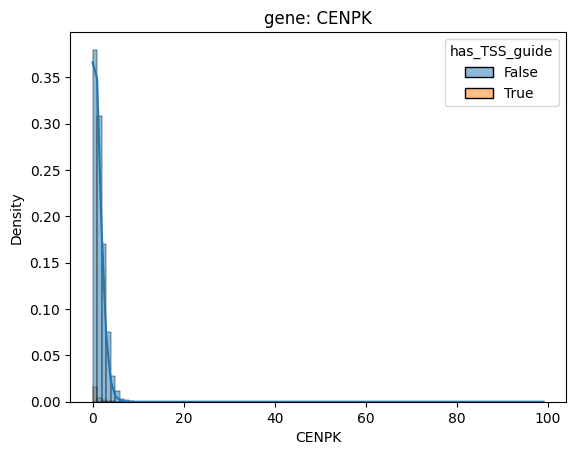

(47964,)
Index(['CENPW_TSS|1', 'CENPW_TSS|2'], dtype='object')
logit=1.49, total_count=14.91


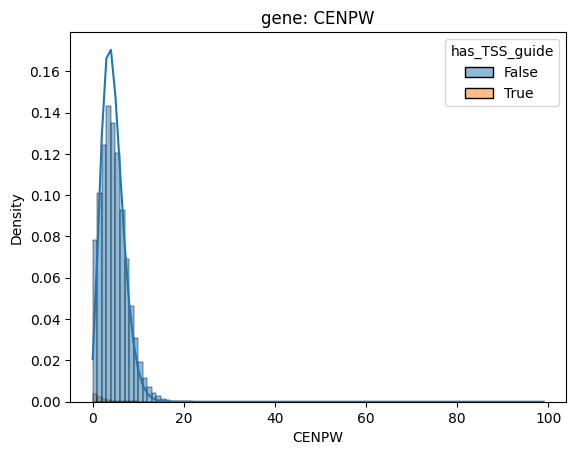

(47964,)
Index(['CERS2_TSS|1', 'CERS2_TSS|2'], dtype='object')
logit=-0.19, total_count=13.15


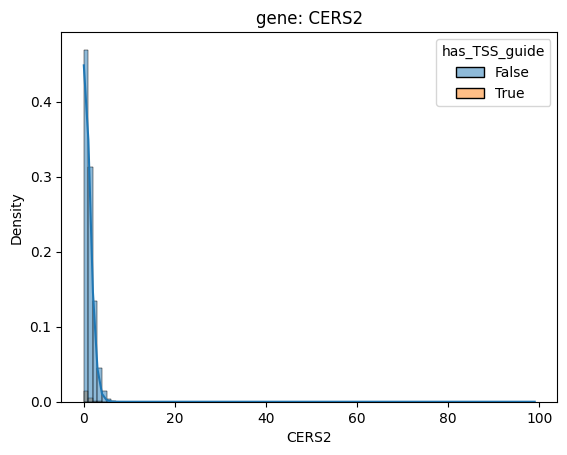

(47964,)
Index(['CHCHD10_TSS|1', 'CHCHD10_TSS|2'], dtype='object')
logit=2.63, total_count=11.26


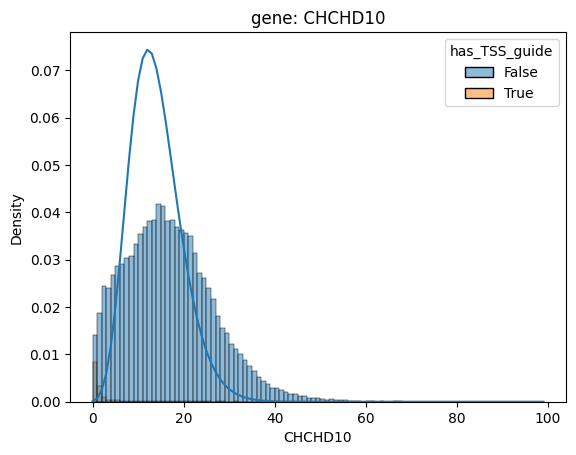

(47964,)
Index(['CHCHD3_TSS|1', 'CHCHD3_TSS|2'], dtype='object')
logit=1.50, total_count=13.68


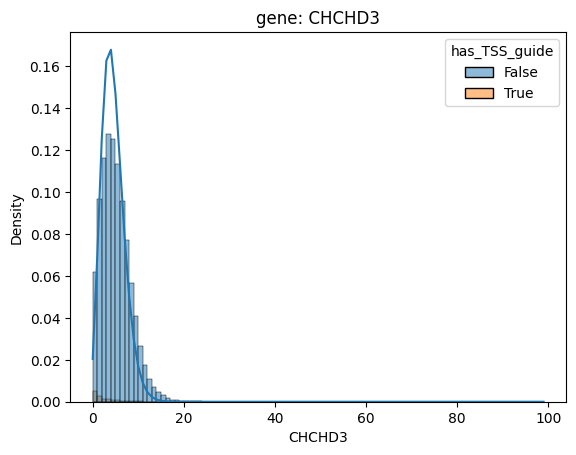

(47964,)
Index(['CHMP1B_TSS|1', 'CHMP1B_TSS|2'], dtype='object')
logit=-0.56, total_count=4.73


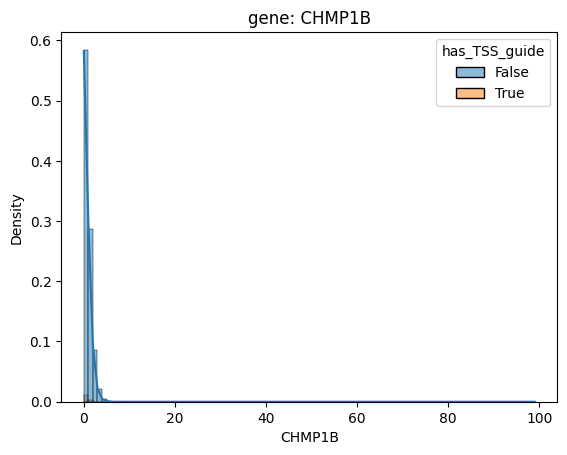

(47964,)
Index(['CHPT1_TSS|1', 'CHPT1_TSS|2'], dtype='object')
logit=1.14, total_count=11.69


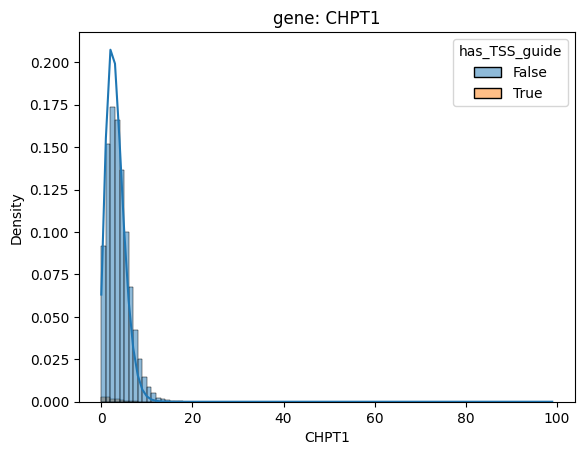

(47964,)
Index(['CHRAC1_TSS|1', 'CHRAC1_TSS|2'], dtype='object')
logit=0.46, total_count=12.16


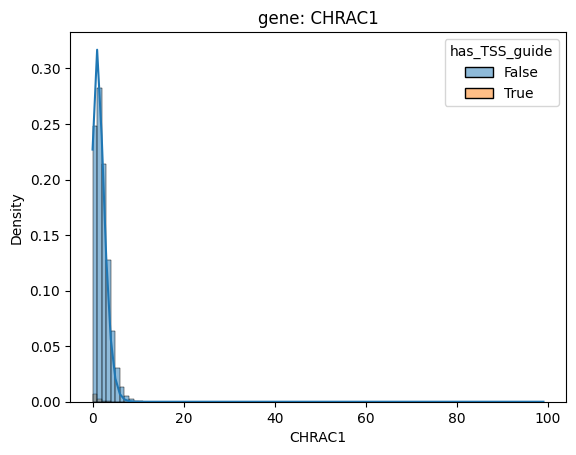

(47964,)
Index(['CITED2_TSS|1', 'CITED2_TSS|2'], dtype='object')
logit=-0.36, total_count=1.07


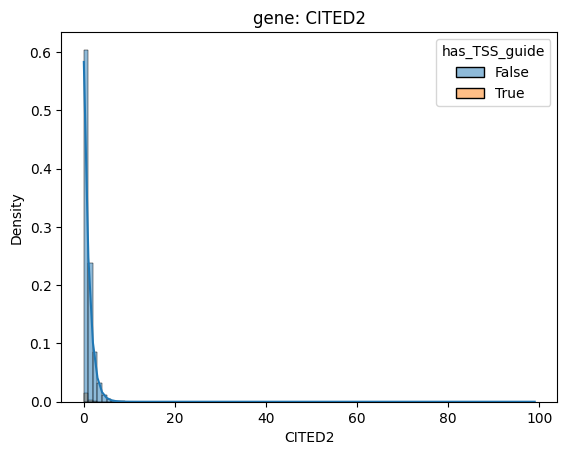

(47964,)
Index(['CKB_TSS|1', 'CKB_TSS|2'], dtype='object')
logit=2.11, total_count=3.92


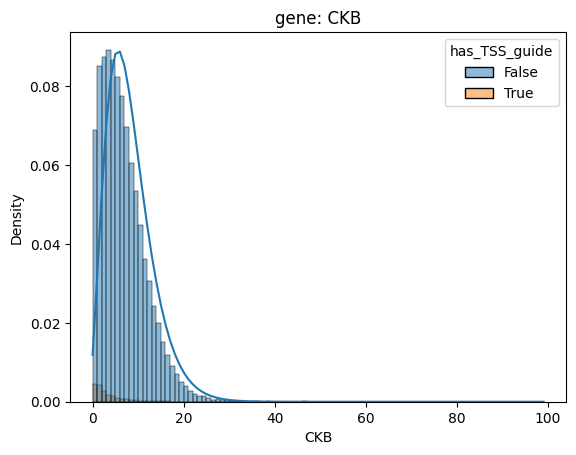

In [ ]:
for sg in selected_genes:
    plot_gene_distribution(model.module.guide.median(), gene_name=sg, log_y_scale=False)

In [ ]:

# for _ in range(10):
#     model.train(
#         10,
#         lr=0.01,
#         batch_size=1024,
#         accelerator=accelerator,
#     )
#     plot_gene_distribution(model.module.guide.median())


# # plan_kwargs = {'optim': pyro.optim.ClippedAdam(dict(lr=0.1, lrd=0.96))}
# # model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)
# # model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)


In [ ]:
# medians = model.module.guide.median()
# log_gene_means = medians["log_gene_mean"]
# log_gene_dispersions = medians["log_gene_dispersion"]
# @interact(gene_idx = (0, mdata["rna"].n_vars), x_max=(0,100))
# def plot_gene_distribution(gene_idx=0, x_max=20, log_y_scale=False):
#     x = torch.tensor(np.arange(x_max))
#     logit = log_gene_means[gene_idx]
#     total_count = log_gene_dispersions[gene_idx].exp()
#     ndist = NegativeBinomial(logits = logit-log_gene_dispersions[gene_idx], total_count=total_count)
#     probs = ndist.log_prob(x).exp()
#     plt.plot(x, probs)
#     plt.hist(mdata["rna"].X[:,gene_idx].todense(), bins=x, density=True)
#     plt.title(f'gene: {mdata["rna"].var_names[gene_idx]}, logit={logit:.2f}, total_count={total_count:.2f}')
#     if log_y_scale:
#         plt.semilogy()

In [ ]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)

AutoGuideList.0.locs.guide_efficacy torch.Size([110, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([110, 1])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([6, 50])
AutoGuideList.0.scales.batch_effect torch.Size([6, 50])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 50])
AutoGuideList.0.scales.cont_covariate_effect torch.Size([3, 50])
perturbo$$$_guide.0.locs.guide_efficacy_unconstrained torch.Size([110, 1])
perturbo$$$_guide.0.locs.log_gene_mean_unconstrained torch.Size([50])
perturbo$$$_guide.0.locs.log_gene_dispersion_unconstrained torch.Size([50])
perturbo$$$_guide.0.locs.batch_effect_unconstrained torch.Size([6, 50])
perturbo$$$_guide.0.locs.cont_covariate_effect_unconstrained torch.Size([3, 50])
perturbo$$$_guide.0.scales.guide_efficacy_uncons

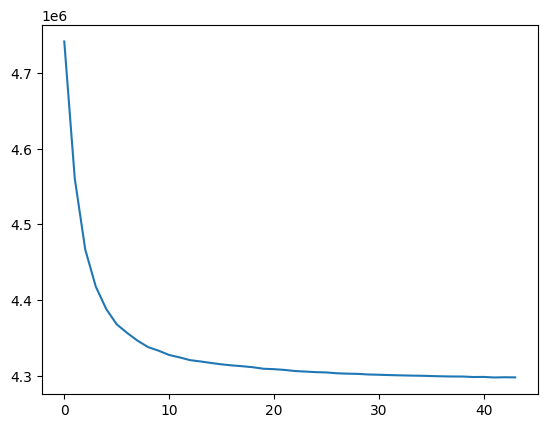

In [ ]:
plt.plot(model.history["elbo_train"])

In [ ]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)

AutoGuideList.0.locs.guide_efficacy torch.Size([110, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([110, 1])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([6, 50])
AutoGuideList.0.scales.batch_effect torch.Size([6, 50])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 50])
AutoGuideList.0.scales.cont_covariate_effect torch.Size([3, 50])
perturbo$$$_guide.0.locs.guide_efficacy_unconstrained torch.Size([110, 1])
perturbo$$$_guide.0.locs.log_gene_mean_unconstrained torch.Size([50])
perturbo$$$_guide.0.locs.log_gene_dispersion_unconstrained torch.Size([50])
perturbo$$$_guide.0.locs.batch_effect_unconstrained torch.Size([6, 50])
perturbo$$$_guide.0.locs.cont_covariate_effect_unconstrained torch.Size([3, 50])
perturbo$$$_guide.0.scales.guide_efficacy_uncons

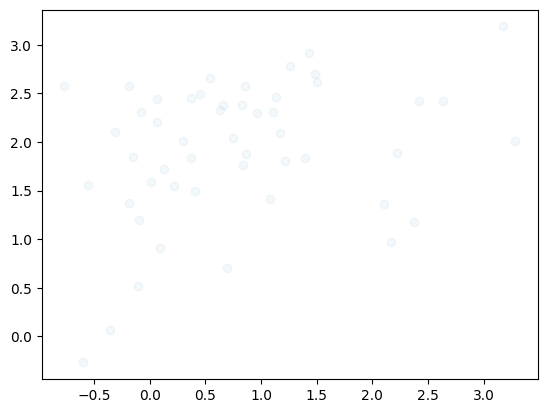

In [ ]:
mean = model.module.guide.median()['log_gene_mean'].numpy()
dispersion = model.module.guide.median()['log_gene_dispersion'].numpy()
plt.scatter(mean, dispersion, alpha=0.05)


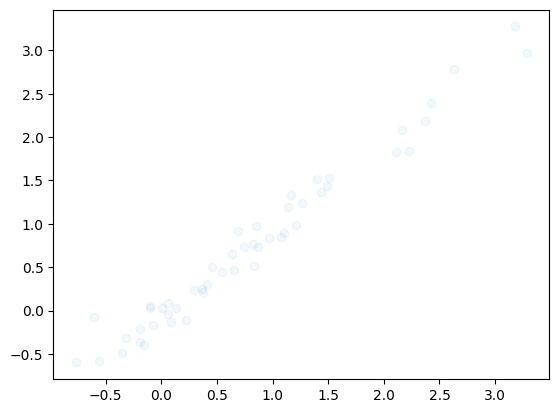

In [ ]:
plt.scatter(mean, np.log(mdata['rna'].X.mean(axis=0).A1), alpha=0.05)


In [ ]:

from scipy.sparse import coo_matrix, issparse

element_effects = model.get_element_effects()
element_effects = element_effects.assign(
    is_target=lambda x: x["element"].str.split("_", expand=True)[0] == x["gene"],
)
element_effects

,loc,scale,element,gene,z_value,q_value,is_target
44,-1.812809,0.015987,CHCHD10_TSS,CHCHD10,-113.392220,0.000000e+00,True
24,-0.887528,0.012068,BTF3_TSS,BTF3,-73.542076,0.000000e+00,True
13,-1.185857,0.029895,ATP6V1F_TSS,ATP6V1F,-39.667877,0.000000e+00,True
3,-0.974516,0.027948,ADIPOR1_TSS,ADIPOR1,-34.868382,2.242079e-266,True
29,-1.421106,0.048776,CALM3_TSS,CALM3,-29.135618,1.270946e-186,True
...,...,...,...,...,...,...,...
98,0.030528,0.028688,chr19:40939563-40939586,BLVRB,1.064131,2.872692e-01,False
87,0.027014,0.024418,chr14:75394016-75394039,ACYP1,1.106308,2.685930e-01,False
94,0.032709,0.024649,chr18:11953198-11953221,CHMP1B,1.326972,1.845179e-01,False
69,0.032803,0.020139,chr11:61809436-61809459,CCDC86,1.628834,1.033482e-01,False


<Axes: >

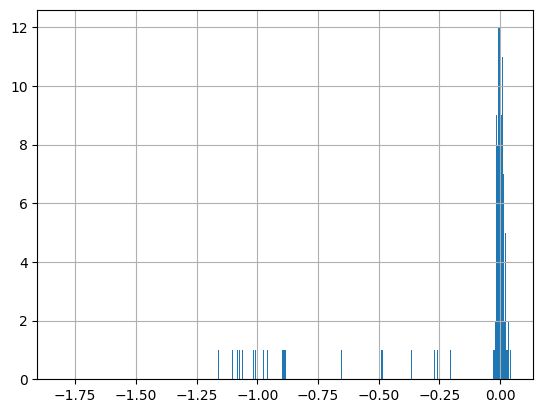

In [ ]:
element_effects['loc'].hist(bins=1000)
# plt.semilogy()
# plt.xlim([-5,5])

/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_31606/3333580445.py:1: FutureWarning: 

The `scale` parameter has been renamed to `width_method` and will be removed in v0.15. Pass `width_method='area', but note that the result for 'area' will appear different.
  sns.boxenplot(element_effects, x="is_target", y="z_value", scale="area")


<Axes: xlabel='is_target', ylabel='z_value'>

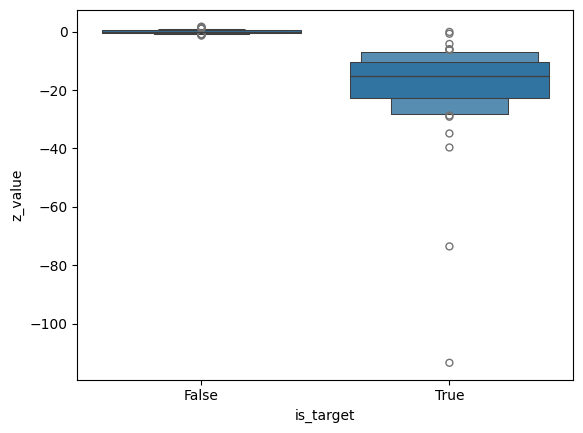

In [ ]:
sns.boxenplot(element_effects, x="is_target", y="z_value", scale="area")

In [ ]:
# scpower_df.sort_values('p_value')
sceptre_df=sceptre_df.assign(element=lambda x: x['guide'].str.split(r'|', regex=False, expand=True)[0])


In [ ]:
merge_df = element_effects.merge(sceptre_df, how="inner", on=["element", "gene"])

if not smoke_test:
    assert len(merge_df)==len(sceptre_df)

# len(merge_df)
# # merge_df.sort_values("SCEPTRE_p_value")

## Visualize hits



In [ ]:
from sklearn.linear_model import LinearRegression

reg_x=(merge_df[["z_value"]].values)
reg_y=(merge_df[["SCEPTRE_z_value"]].values)
reg = LinearRegression(fit_intercept=False).fit(reg_x, reg_y)
print("slope:", reg.coef_[0,0])
print("R^2:", reg.score(reg_x, reg_y))


slope: 0.49864718
R^2: 0.7660409634404243


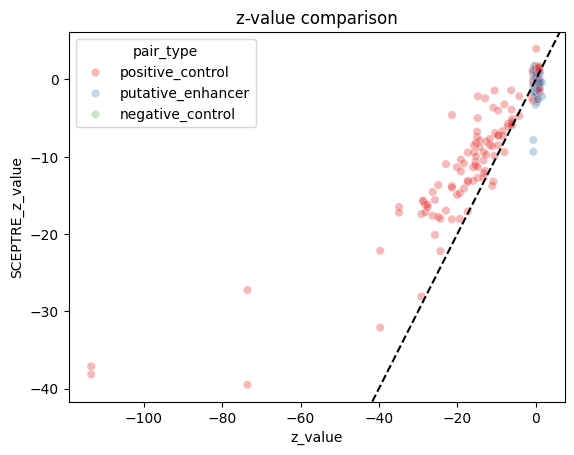

In [ ]:
plt.title("z-value comparison")
sns.scatterplot(merge_df, x='z_value', y='SCEPTRE_z_value', hue='pair_type', alpha=0.3, palette='Set1')
plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
plt.show()


## Interactive data visualization
Need to subset and clip the data so that we can plot interactively

(1e-21, 2)

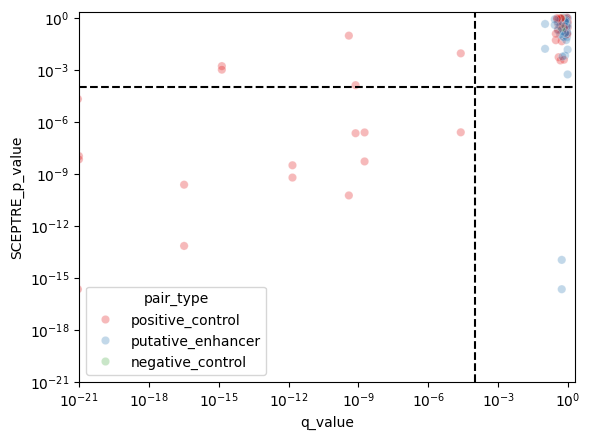

In [ ]:
# merge_df['p_value'] = np.maximum(merge_df['p_value'], min_p_value)

sns.scatterplot(merge_df, x="q_value", y="SCEPTRE_p_value", hue="pair_type", alpha=0.3, palette="Set1")
# plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
plt.axhline(1e-4, c='black', linestyle='dashed')
plt.axvline(1e-4,  c='black', linestyle='dashed')

plt.loglog()
# plt.legend()
plt.xlim(1e-21, 2)
plt.ylim(1e-21, 2)

In [ ]:
min_p_value = 1e-100

subset_results = merge_df.query("q_value<0.01 or SCEPTRE_p_value < 0.01").copy()
# subset_results = merge_df.query("p_value<1e-5")
subset_results['p_value'] = np.maximum(subset_results['q_value'], min_p_value)
subset_results

,loc,scale,element,gene,z_value,q_value,is_target,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change,p_value
0,-1.812809,0.015987,CHCHD10_TSS,CHCHD10,-113.392220,0.000000,True,CHCHD10_TSS|1,positive_control,2.220446e-16,-38.174558,-1.769527,1.000000e-100
1,-1.812809,0.015987,CHCHD10_TSS,CHCHD10,-113.392220,0.000000,True,CHCHD10_TSS|2,positive_control,2.220446e-16,-37.144596,-1.268803,1.000000e-100
2,-0.887528,0.012068,BTF3_TSS,BTF3,-73.542076,0.000000,True,BTF3_TSS|1,positive_control,2.220446e-16,-27.260327,-0.798275,1.000000e-100
3,-0.887528,0.012068,BTF3_TSS,BTF3,-73.542076,0.000000,True,BTF3_TSS|2,positive_control,2.220446e-16,-39.518414,-0.861200,1.000000e-100
4,-1.185857,0.029895,ATP6V1F_TSS,ATP6V1F,-39.667877,0.000000,True,ATP6V1F_TSS|1,positive_control,2.220446e-16,-32.108832,-1.060069,1.000000e-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,-0.016113,0.026128,chr12:4262588-4262611,CCND2,-0.616703,0.537431,False,chr12:4262588-4262611|2,putative_enhancer,2.220446e-16,-9.361752,-0.656345,5.374309e-01
135,-0.001368,0.028555,chr11:129876786-129876809,APLP2,-0.047891,0.961803,False,chr11:129876786-129876809|1,putative_enhancer,5.304688e-04,-3.266048,-0.205079,9.618033e-01
153,0.008339,0.026183,chr12:102249040-102249063,CHPT1,0.318485,0.750117,False,chr12:102249040-102249063|1,putative_enhancer,6.553112e-03,-2.894946,-0.134391,7.501168e-01
158,0.010760,0.025015,PRKAR2B_TSS,BCAP29,0.430149,0.667087,False,PRKAR2B_TSS|2,positive_control,3.736038e-03,-2.554407,-0.116897,6.670872e-01


In [ ]:
pos_controls = merge_df.query("pair_type=='positive_control'")
pos_controls=pos_controls[~pos_controls['gene'].str.contains("-AS")] # remove alt start sites
pos_controls=pos_controls.assign(
    perturbo_rank=lambda x: x.groupby('guide')['q_value'].rank(),
    perturbo_p_rank=lambda x: x.groupby('guide')['z_value'].rank(),
    SCEPTRE_p_rank=lambda x: x.groupby('guide')['SCEPTRE_p_value'].rank(),
    SCEPTRE_z_rank=lambda x: x.groupby('guide')['SCEPTRE_z_value'].rank()
)
pos_controls

,loc,scale,element,gene,z_value,q_value,is_target,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change,perturbo_rank,perturbo_p_rank,SCEPTRE_p_rank,SCEPTRE_z_rank
0,-1.812809,0.015987,CHCHD10_TSS,CHCHD10,-113.392220,0.000000,True,CHCHD10_TSS|1,positive_control,2.220446e-16,-38.174558,-1.769527,1.0,1.0,1.0,1.0
1,-1.812809,0.015987,CHCHD10_TSS,CHCHD10,-113.392220,0.000000,True,CHCHD10_TSS|2,positive_control,2.220446e-16,-37.144596,-1.268803,1.0,1.0,1.0,1.0
2,-0.887528,0.012068,BTF3_TSS,BTF3,-73.542076,0.000000,True,BTF3_TSS|1,positive_control,2.220446e-16,-27.260327,-0.798275,1.0,1.0,1.0,1.0
3,-0.887528,0.012068,BTF3_TSS,BTF3,-73.542076,0.000000,True,BTF3_TSS|2,positive_control,2.220446e-16,-39.518414,-0.861200,1.0,1.0,1.0,1.0
4,-1.185857,0.029895,ATP6V1F_TSS,ATP6V1F,-39.667877,0.000000,True,ATP6V1F_TSS|1,positive_control,2.220446e-16,-32.108832,-1.060069,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,0.021235,0.023765,PSMG2_TSS,CHMP1B,0.893546,0.371565,False,PSMG2_TSS|2,positive_control,2.110067e-01,-0.598618,-0.034001,1.0,1.0,1.0,1.0
173,0.023504,0.024506,PRPF38A_TSS,BTF3L4,0.959128,0.337494,False,PRPF38A_TSS|1,positive_control,9.353537e-01,1.598019,0.087237,1.0,1.0,1.0,1.0
174,0.023504,0.024506,PRPF38A_TSS,BTF3L4,0.959128,0.337494,False,PRPF38A_TSS|2,positive_control,8.311978e-01,1.099512,0.064149,1.0,1.0,1.0,1.0
175,0.025498,0.024552,PNO1_TSS,C1D,1.038524,0.299026,False,PNO1_TSS|1,positive_control,4.980298e-02,-1.640914,-0.122479,1.0,1.0,1.0,1.0


In [ ]:
target_pairs = pos_controls.query('is_target')
print("our accuracy: "+str(len(target_pairs.query('perturbo_rank==1'))/len(target_pairs)))
print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_z_rank==1'))/len(target_pairs)))
print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_p_rank==1'))/len(target_pairs)))

our accuracy: 1.0
SCEPTRE accuracy: 1.0
SCEPTRE accuracy: 1.0


In [ ]:
# target_pairs.query('perturbo_rank==1 and SCEPTRE_z_rank>=2')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]
target_pairs.query('perturbo_rank==1 and SCEPTRE_p_rank>1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]
# target_pairs.query('perturbo_rank>1 and SCEPTRE_p_rank==1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]

,guide,gene,perturbo_rank,SCEPTRE_p_rank


In [ ]:
target_pairs.query('perturbo_rank>1 and SCEPTRE_p_rank==1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]

,guide,gene,perturbo_rank,SCEPTRE_p_rank


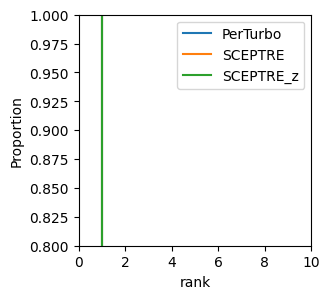

In [ ]:
with plt.rc_context({"figure.figsize": [3,3]}):

  sns.ecdfplot(pos_controls.query('is_target'), x='perturbo_rank',stat="proportion", label="PerTurbo")
  sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_p_rank',stat="proportion", label="SCEPTRE")
  sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_z_rank',stat="proportion", label="SCEPTRE_z")
  plt.legend()
  # plt.title("eCDF")
  # plt.semilogy()
  plt.xlabel("rank")
  plt.xlim([0,10])
  plt.ylim(0.8, 1)
  plt.show()

0.9969743364365534 0.9949206152647122


Text(0.5, 1.0, 'perturbo vs. SCEPTRE p-values')

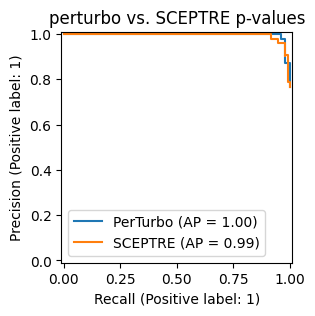

In [ ]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve

with plt.rc_context({"figure.figsize": [3,3]}):
  roc = PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], 1-pos_controls['z_value'], name="PerTurbo")
  PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], 1-pos_controls['SCEPTRE_p_value'], ax=roc.ax_, name="SCEPTRE")

precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['z_value'])
score1=average_precision_score(pos_controls['is_target'], 1-pos_controls['z_value'])
score2=average_precision_score(pos_controls['is_target'], 1-pos_controls['SCEPTRE_p_value'])
print(score1, score2)
plt.title("perturbo vs. SCEPTRE p-values")
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)


0.9969743364365534 0.9944511762843098


Text(0.5, 1.0, 'z-values')

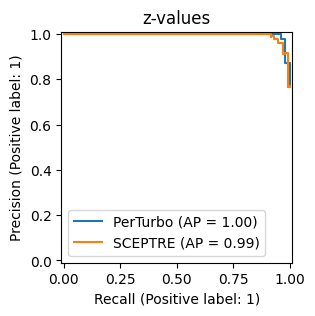

In [ ]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve

with plt.rc_context({"figure.figsize": [3,3]}):
  roc = PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], -pos_controls['z_value'], name="PerTurbo")
  PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], -pos_controls['SCEPTRE_z_value'], ax=roc.ax_, name="SCEPTRE")


precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['z_value'])
score1=average_precision_score(pos_controls['is_target'], -pos_controls['z_value'])
score2=average_precision_score(pos_controls['is_target'], -pos_controls['SCEPTRE_z_value'])
print(score1, score2)
plt.title('z-values')
# plt.title()
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)


## experimental/future 

In [ ]:
# len(merge_df)
# len(sceptre_df)
# model.module.guide.median()['element_x_factor'].min()
loc, scale = model.module.guide._get_loc_and_scale("factor_x_gene")
factor_x_gene_z_score = (loc/scale).detach().numpy()

factor_x_gene_df = pd.DataFrame(
    factor_x_gene_z_score,
    columns = mdata['rna'].var_names
)
# sns.heatmap(factor_x_gene_df, cmap="vlag", center=0, vmin=-5, vmax=5)

sns.clustermap(factor_x_gene_df.T, cmap="vlag", center=0, vmin=-5, vmax=5, metric="cosine", figsize=(16,16))


AttributeError: 'AutoGuideList' object has no attribute '_get_loc_and_scale'

In [ ]:
# factor_x_gene_df.loc[5].sort_values()[-20:].index

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


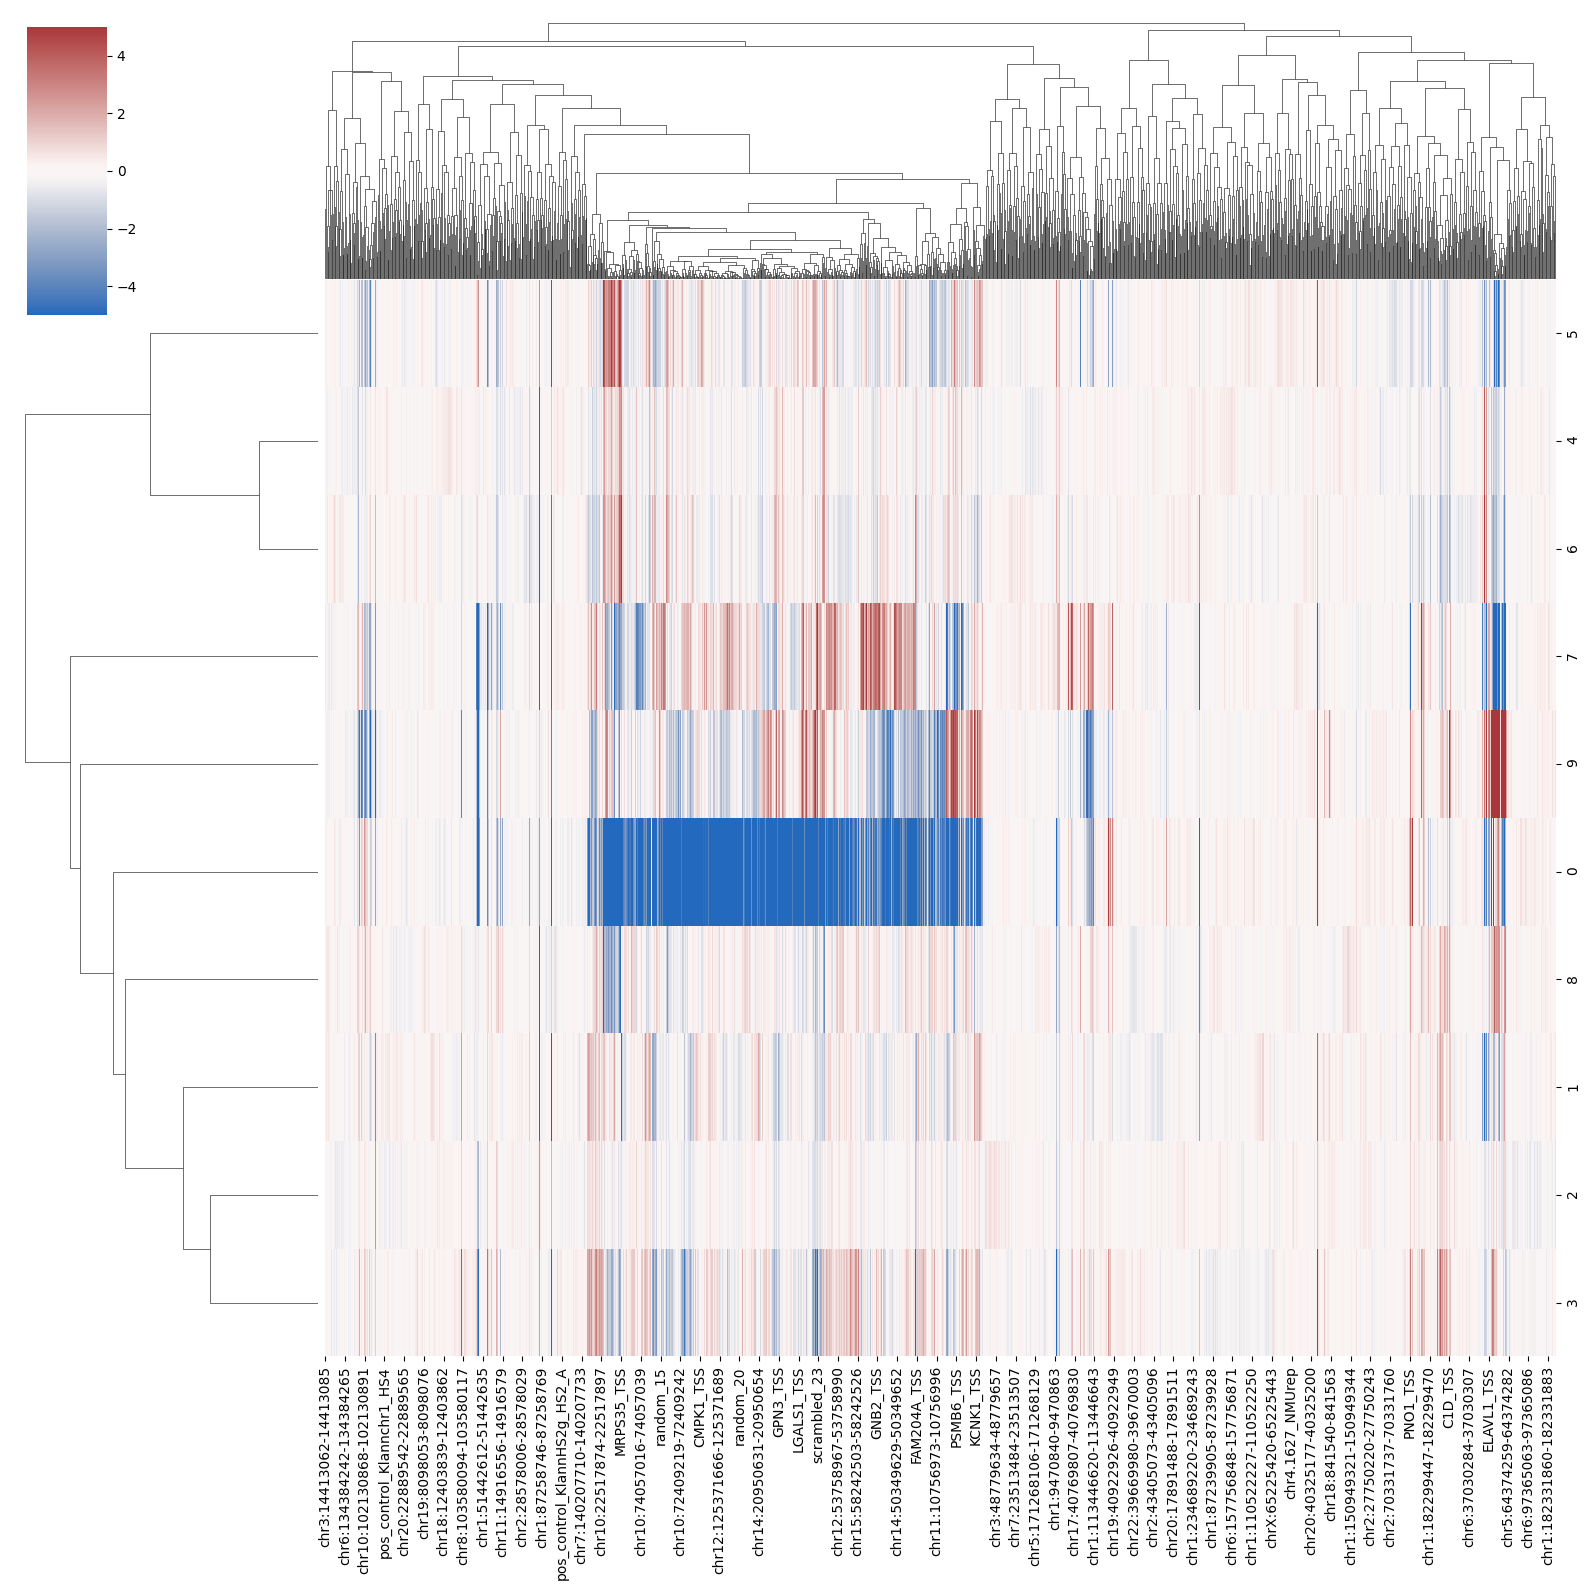

In [ ]:
loc, scale = model.module.guide._get_loc_and_scale("element_x_factor")
element_x_factor_z_score = (loc/scale).detach().numpy()

element_x_factor_df = pd.DataFrame(
    element_x_factor_z_score,
    index= mdata['grna'].varm['element_targeted'].columns
)
# sns.heatmap(element_x_factor_df, cmap="vlag", center=0)

sns.clustermap(element_x_factor_df.T, cmap="vlag", center=0, vmin=-5, vmax=5, metric="cosine",  figsize=(16,16))

# biggest_gene = model.module.guide.median()['factor_x_gene'][biggest_factor_idx, :].argmax()
# biggest_element = model.module.guide.median()['element_x_factor'][:, biggest_factor_idx].argmax()

# elements =  mdata['grna'].varm['element_targeted'].columns
# genes = mdata['rna'].var_names

# plt.bar(x=values[:10].numpy(), height=)

# mdata['grna'].varm['element_targeted'].columns[int(biggest_element)]
# mdata['rna'].var_names[int(biggest_gene)]

In [ ]:
# plt.plot(np.log(threshold), precision[:-1])

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# guide_1 = f"{plot_gene}_TSS|1"
# guide_2 = f"{plot_gene}_TSS|2"

gene_select = widgets.Dropdown(
    options=sorted(mdata['rna'].var_names),
    value=mdata['rna'].var_names[0],
    # rows=10,
    description='Gene',
    disabled=False
)


guide_select = widgets.Dropdown(
    options=sorted(mdata['grna'].var_names),
    value=mdata['grna'].var_names[0],
    # rows=10,
    description='Guide',
    disabled=False
)

display(gene_select, guide_select)

Dropdown(description='Gene', options=('ACTB', 'ACTG1', 'ACYP1', 'ADIPOR1', 'ALDH1A2'), value='ACTB')

Dropdown(description='Guide', options=('ACTB_TSS|1', 'ACTB_TSS|2', 'ACTG1_TSS|1', 'ACTG1_TSS|2', 'ACYP1_TSS|1'…

In [ ]:
# import scanpy as sc

# plot_guides = ['TMED10_TSS|1','TMED10_TSS|2']
# plot_genes = ['TMED10', 'KDELR2','KDELR3','SEC13', 'YIF1A', 'CALU', 'YIPF2', 'SDF2L1', 'MANF']

plot_genes = [gene_select.value]
plot_guides = [guide_select.value]


counts_df = mdata["rna"][:, plot_genes].to_df()
guide_obs = mdata["grna"][:, plot_guides].X.sum(axis=1).copy().astype(bool)
counts_df['guide_obs']=guide_obs


# mdata['rna'].obs['TMED10_TSS'] = guide_obs
# mdata['rna'].obs['TMED10_TSS']=mdata['rna'].obs['TMED10_TSS'].astype("category")
# # mdata['rna'].raw = mdata['rna']
# # sc.pp.normalize_total(mdata['rna'])
# with plt.rc_context({'figure.dpi':200}):
#   sc.pl.dotplot(mdata['rna'], plot_genes, groupby='TMED10_TSS', title='TMED10_TSS')

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be r

(0.0, 50.0)

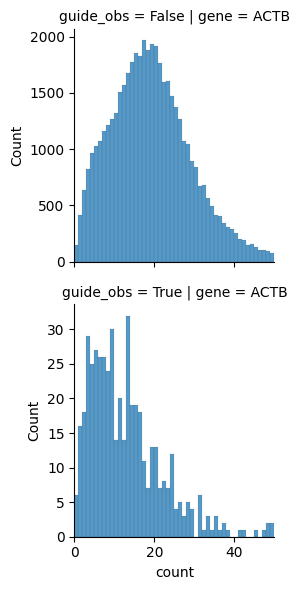

In [ ]:
# plot_gene = gene_select.value
# plot_guide = guide_select.value
# print(plot_gene, plot_guide)

# plot_df = pd.DataFrame({"count": counts, "has_guide": guide_obs})
plot_df = counts_df.melt(id_vars='guide_obs',var_name='gene',value_name='count')
g = sns.FacetGrid(plot_df, col="gene", row="guide_obs",sharey=False)
g.map_dataframe(
    sns.histplot,
    x="count", binwidth=1,
    hue_order=[False,True],
    # log_scale=[False,True]
)
plt.xlim(0,50)
# plt.semilogy()

# sns.histplot(
#     plot_df.query('has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# plt.show()
# sns.histplot(
#     plot_df.query('not has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# # plt.xlim(0, 50)
# g.title(f"gene: {plot_gene}, guide: {plot_guide}")
# plt.show()



In [ ]:
!pwd

/Users/ljb80/Projects/perturbo/docs/notebooks


In [ ]:
import altair as alt

alt.Chart(subset_results).mark_point().encode(
  x='z_value',
  y='SCEPTRE_z_value',
  color='is_target',
  tooltip=['guide','gene', 'z_value', 'SCEPTRE_z_value'] 
).interactive()


ModuleNotFoundError: No module named 'altair'

#### scpower_df.to_csv(f"{data_dir}/scpower_results.csv")